# Phase 4 — Exploratory Data Analysis

**Project:** PLI Scheme — Export Trajectory, Counterfactual and Volatility Analysis
**Stage:** EDA only. **Diagnosis, not model selection.**

> **Binding constraint.** Nothing in this notebook may alter a locked specification.
> The design is fixed in `08_report/research_design_memo.md` and in Decision Log entries
> D-001, D-002 and D-003. Baskets, intervention dates, the study window, the forecast
> horizon, the volatility windows, the COVID definition and the control set are all
> **locked**. Anything this notebook reveals is recorded as a *diagnostic finding* or an
> *interpretation caveat* — never as a reason to re-specify.
>
> **No ITS, forecasting, volatility inference, control or robustness model is estimated here.**

Outputs: `06_results/EDA_summary.csv`, `07_figures/*.png`, `08_report/EDA_findings.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import eda_core as E
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

df = E.load()
print("panel:", df.shape, "| baskets:", df.basket_id.nunique(), "| months:", df.month.nunique())
print("window:", df.month.min(), "->", df.month.max())
print("\nlocked intervention dates:"); print(E.D_S)

# inline display of figures saved to ../07_figures (same files, no duplicates)
from IPython.display import Image, display
def show(figs):
    if figs is None: return
    if isinstance(figs, str): figs = [figs]
    for f in figs:
        if f: display(Image(filename=f"../07_figures/{f}"))

panel: (672, 19) | baskets: 7 | months: 96
window: 2018-04 -> 2026-03

locked intervention dates:
{'B1_MOBILE': '2020-08', 'B2_PHARMA': '2022-04', 'B3_AC': '2022-04', 'B4_TEXTILE': '2024-04'}


## 0. Overview — all treated baskets on one log scale

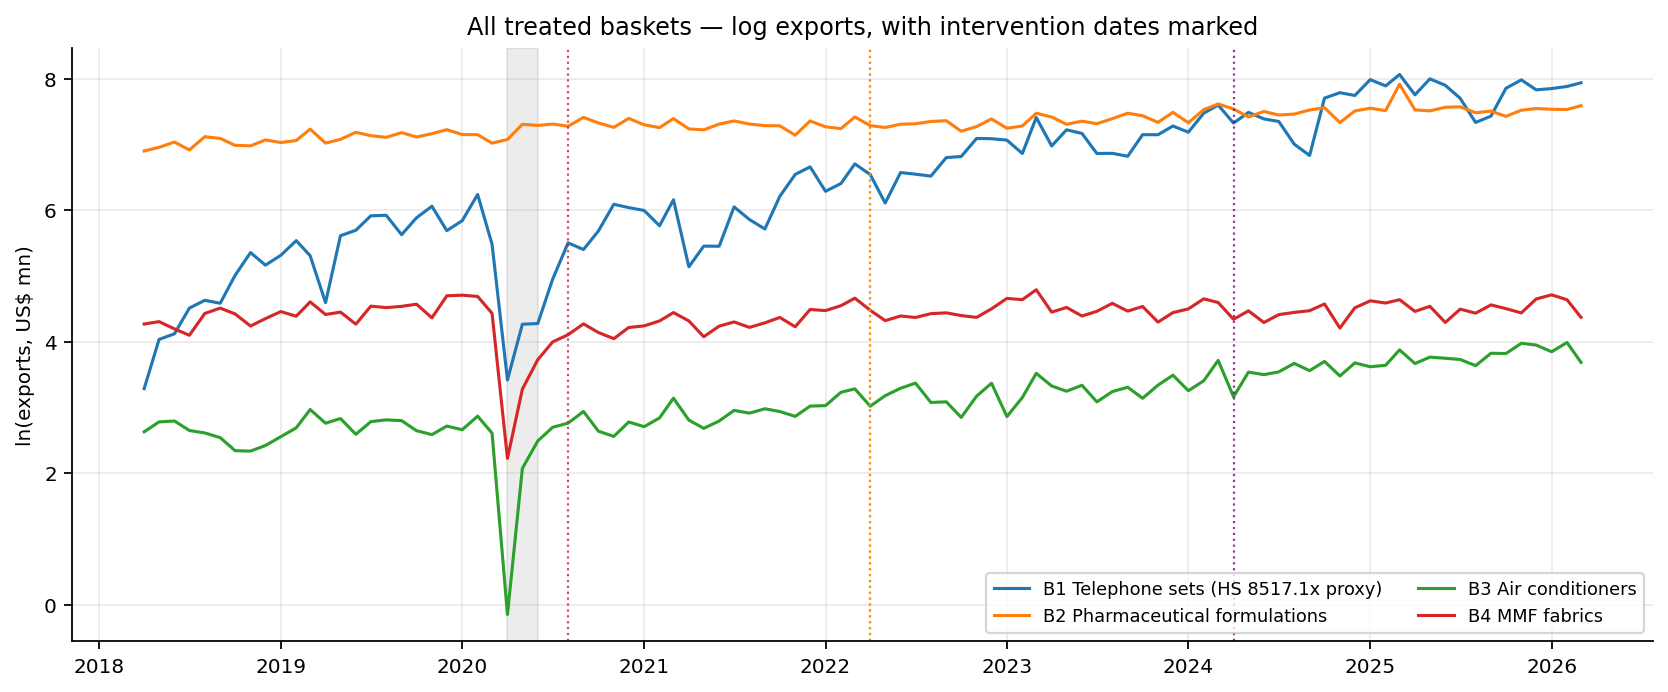

In [2]:
show(E.plot_overview(df))

## 1–3. Levels, log exports, monthly log growth

`g_t = 100 x [ln(Y_t) - ln(Y_{t-1})]`. D_s marked in red; the locked COVID block
(Apr–Jun 2020) shaded.

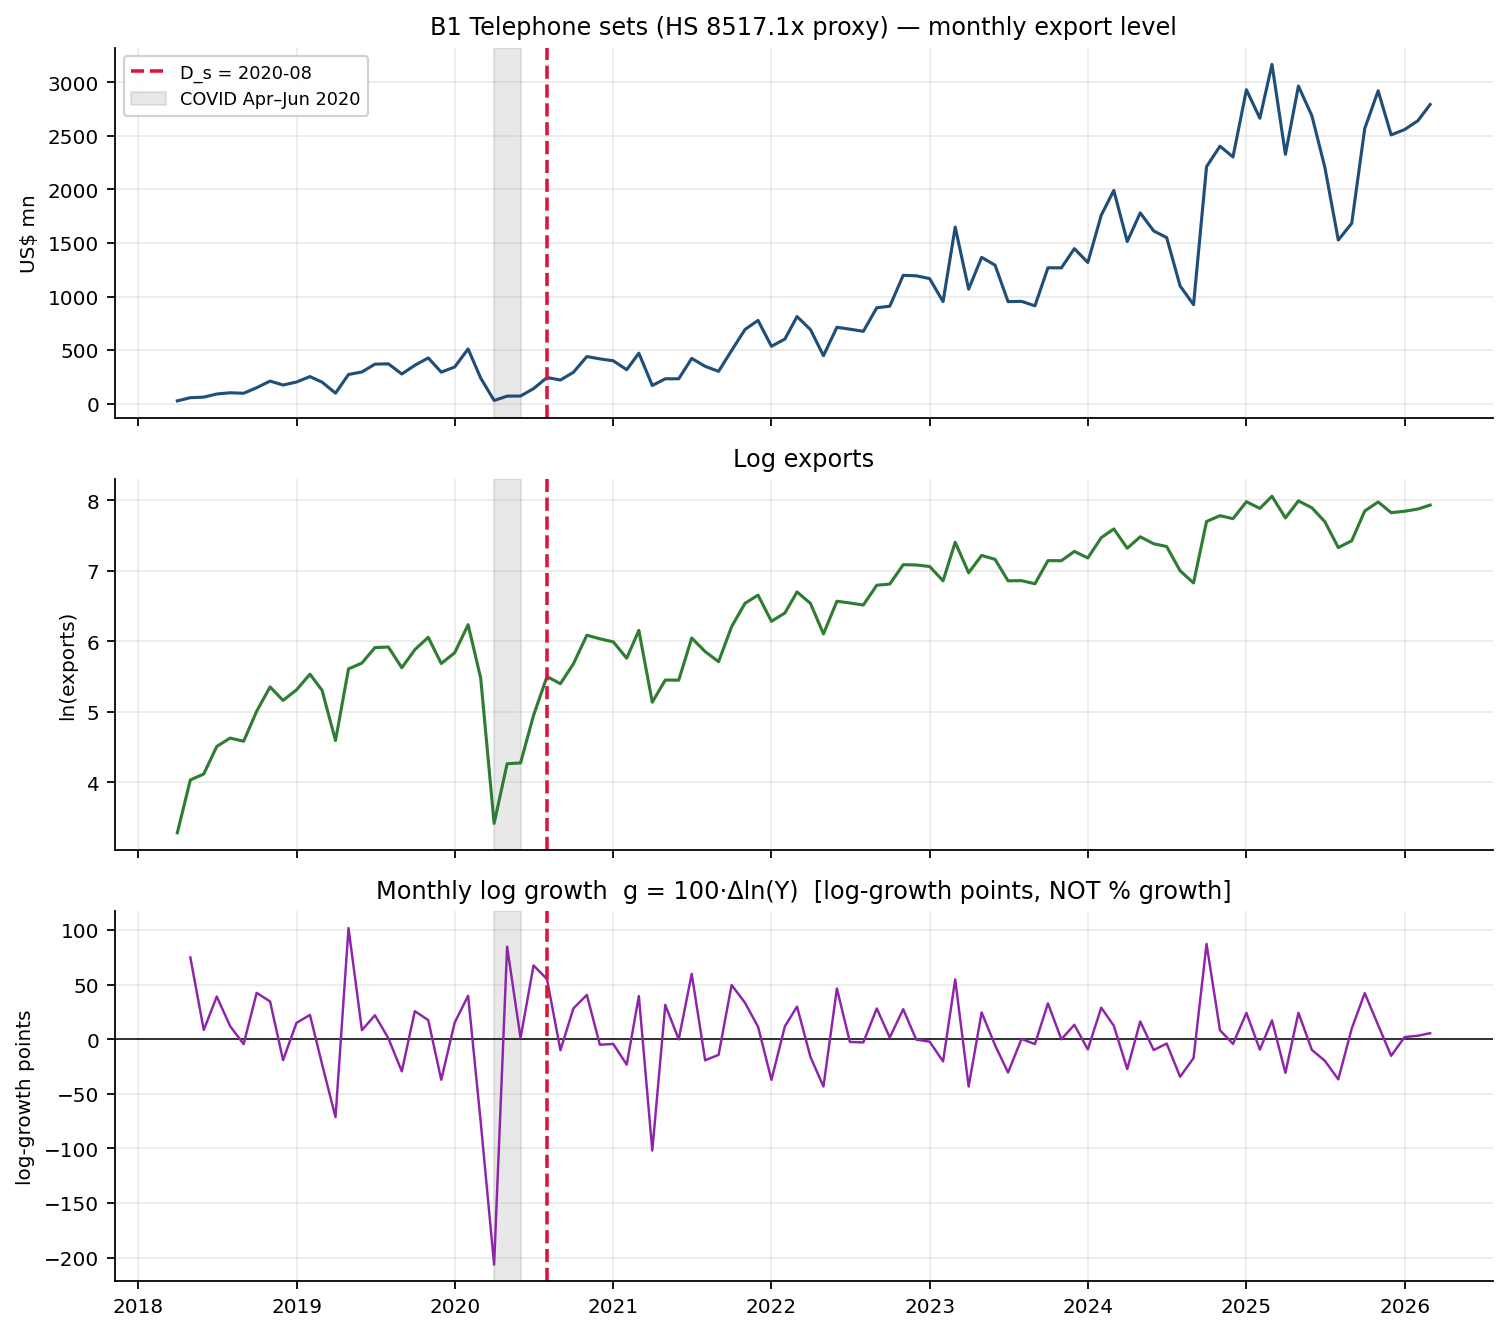

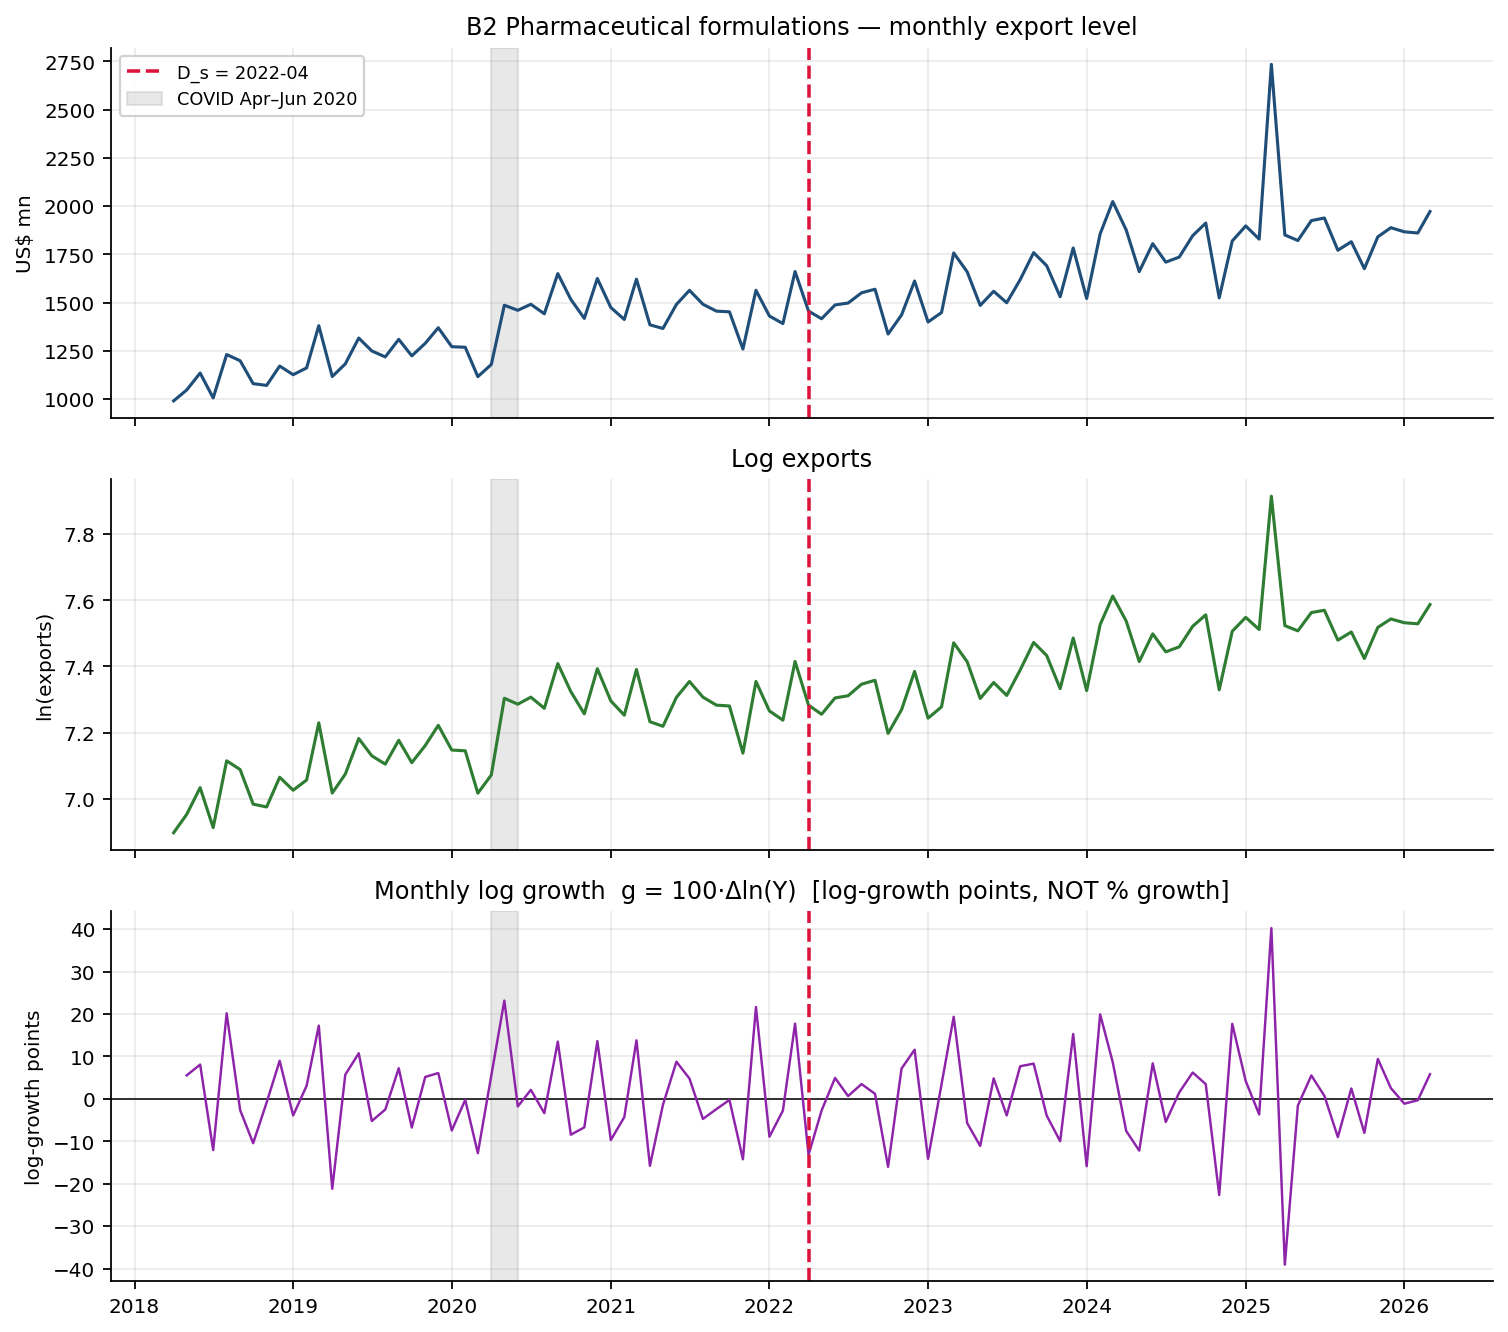

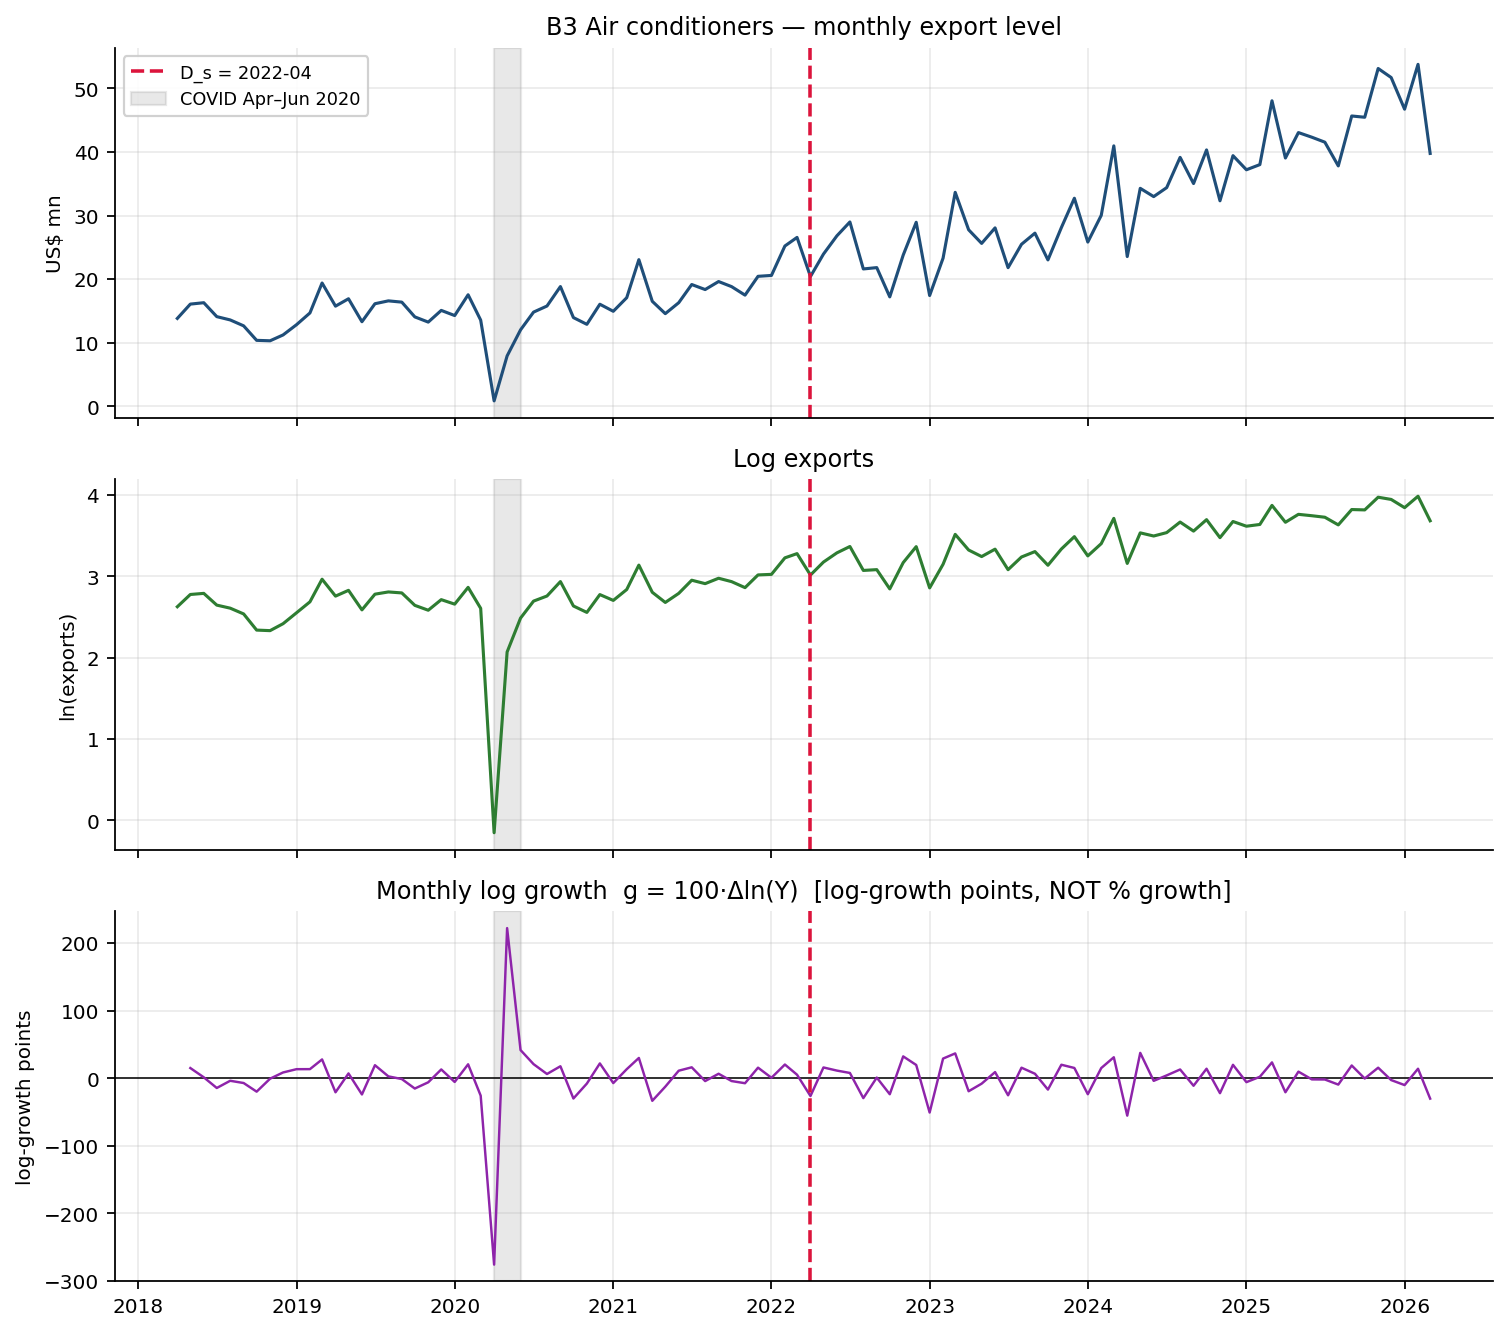

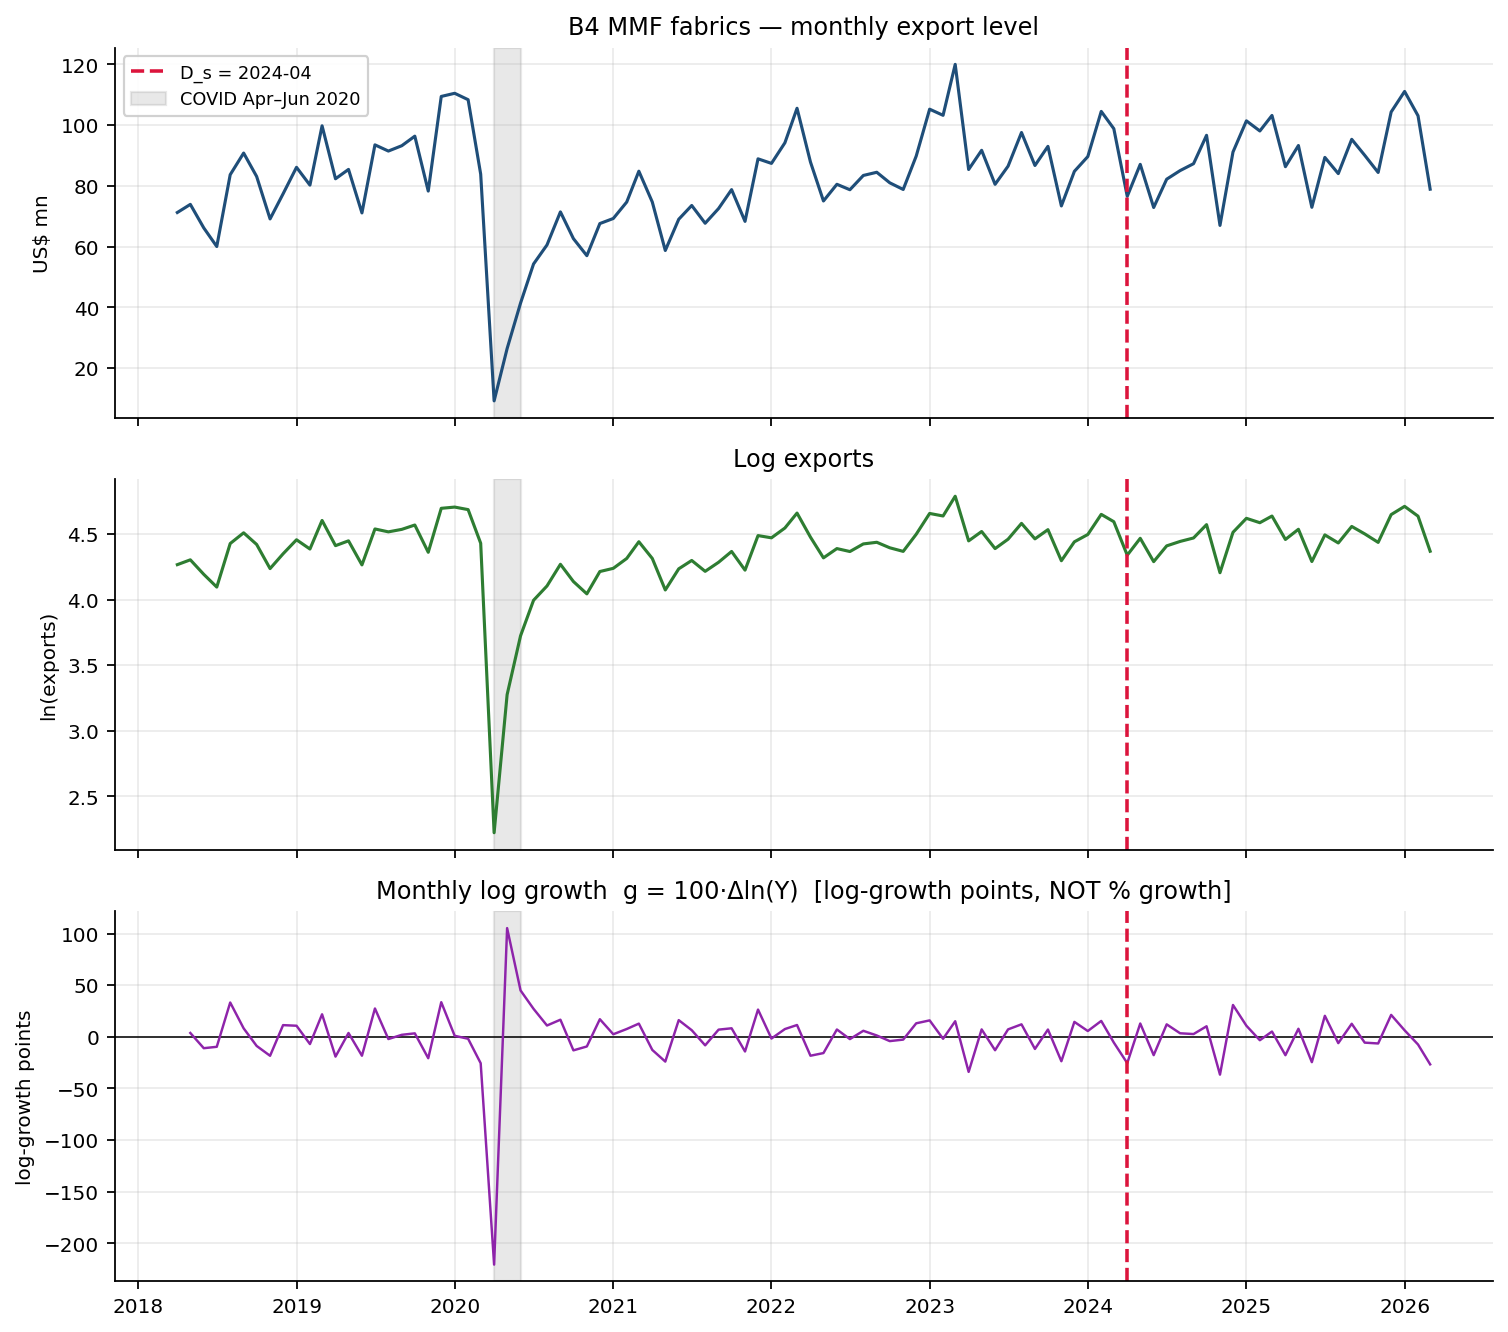

,basket_id,n,n_pre,n_post,level_min,level_max,level_mean,ratio_max_min,growth_sd_full,growth_sd_pre,growth_sd_post,growth_min,growth_max,n_growth_pre,n_growth_post
0,B1_MOBILE,96,28,68,26.65,3166.91,985.20,118.8,40.25,59.52,29.96,-206.47,101.78,27,68
1,B2_PHARMA,96,48,48,990.19,2735.13,1524.26,2.8,11.43,10.37,12.47,-39.07,40.25,47,48
2,B3_AC,96,48,48,0.86,53.79,24.48,62.5,41.22,54.77,21.50,-275.79,222.15,47,48
3,B4_TEXTILE,96,72,24,9.23,119.97,82.76,13.0,29.75,33.05,17.13,-220.66,105.24,71,24


In [3]:
show(E.plot_level_log_growth(df))
E.descriptives(df)

## 4. Seasonality — month-of-year pattern

Left: distribution of monthly log growth by calendar month.
Right: mean deviation of log level from that year's own mean, by month.

*Caveat for fast-growing series:* the right-hand profile mixes within-year trend with
season. For a basket growing strongly inside the year this inflates the apparent
"late months high / April low" pattern. **STL (section 5) is the cleaner read**, because
it separates trend from season explicitly.

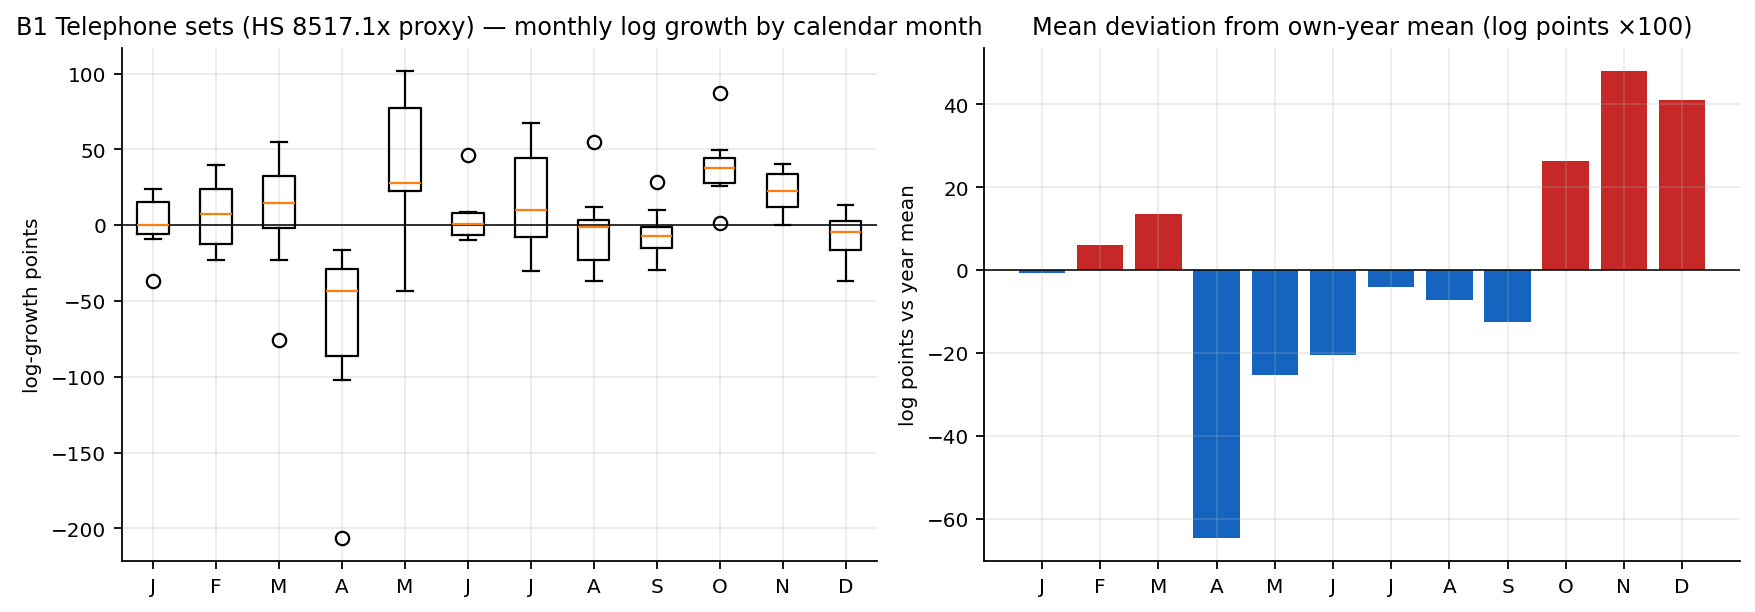

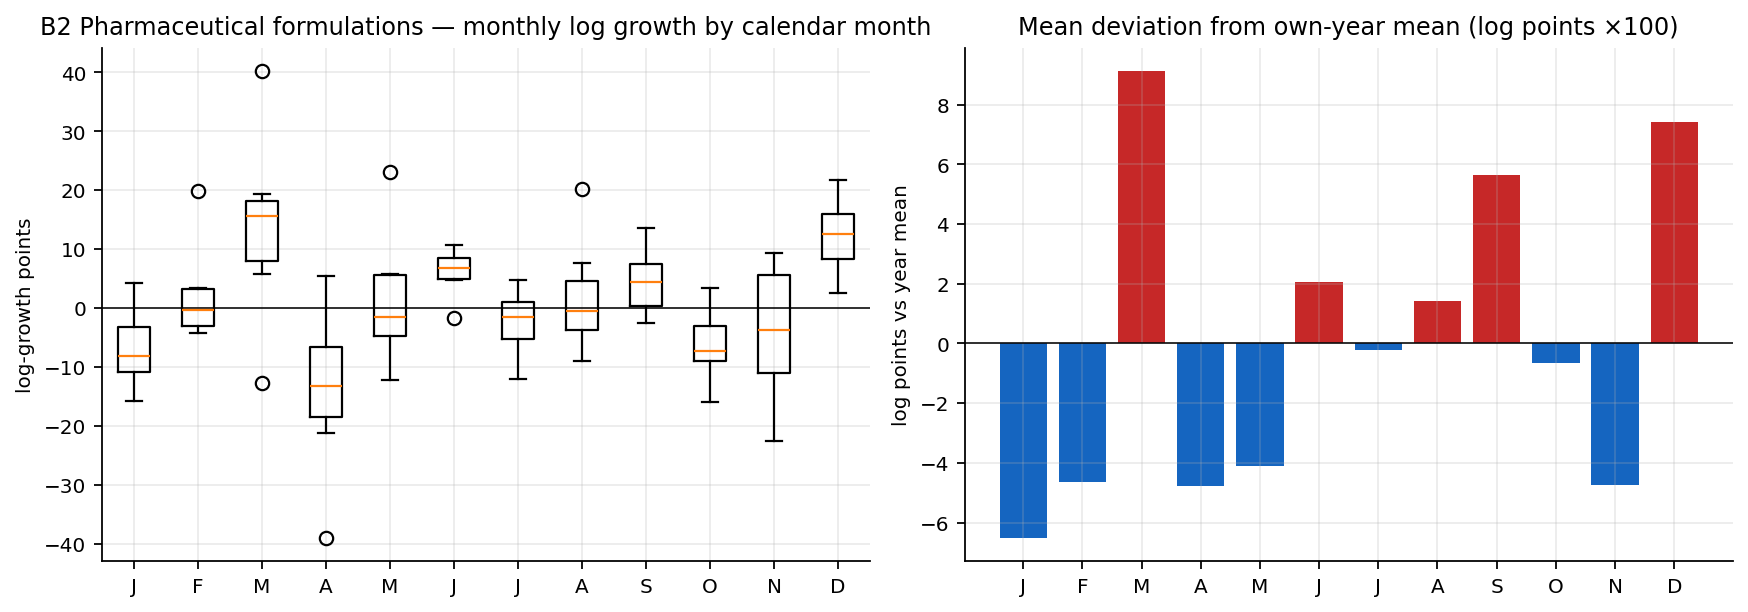

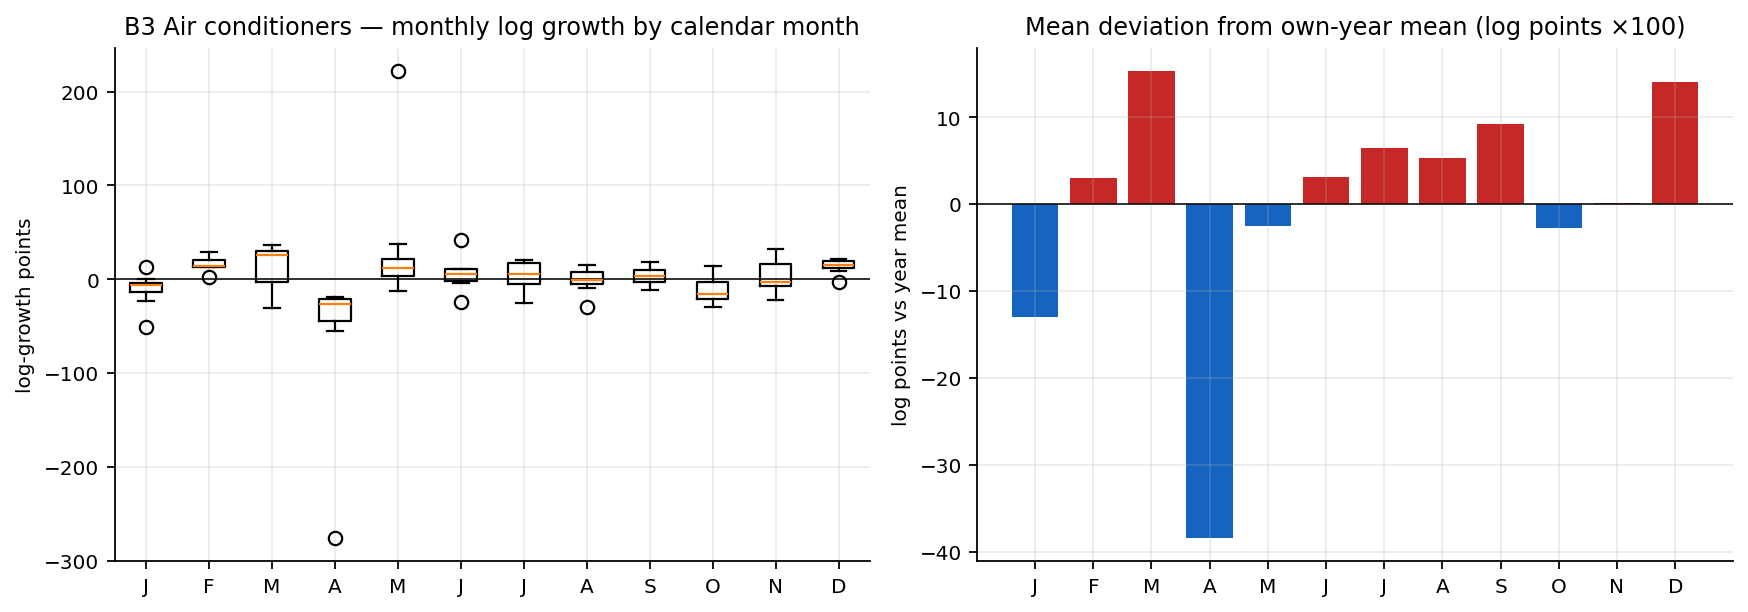

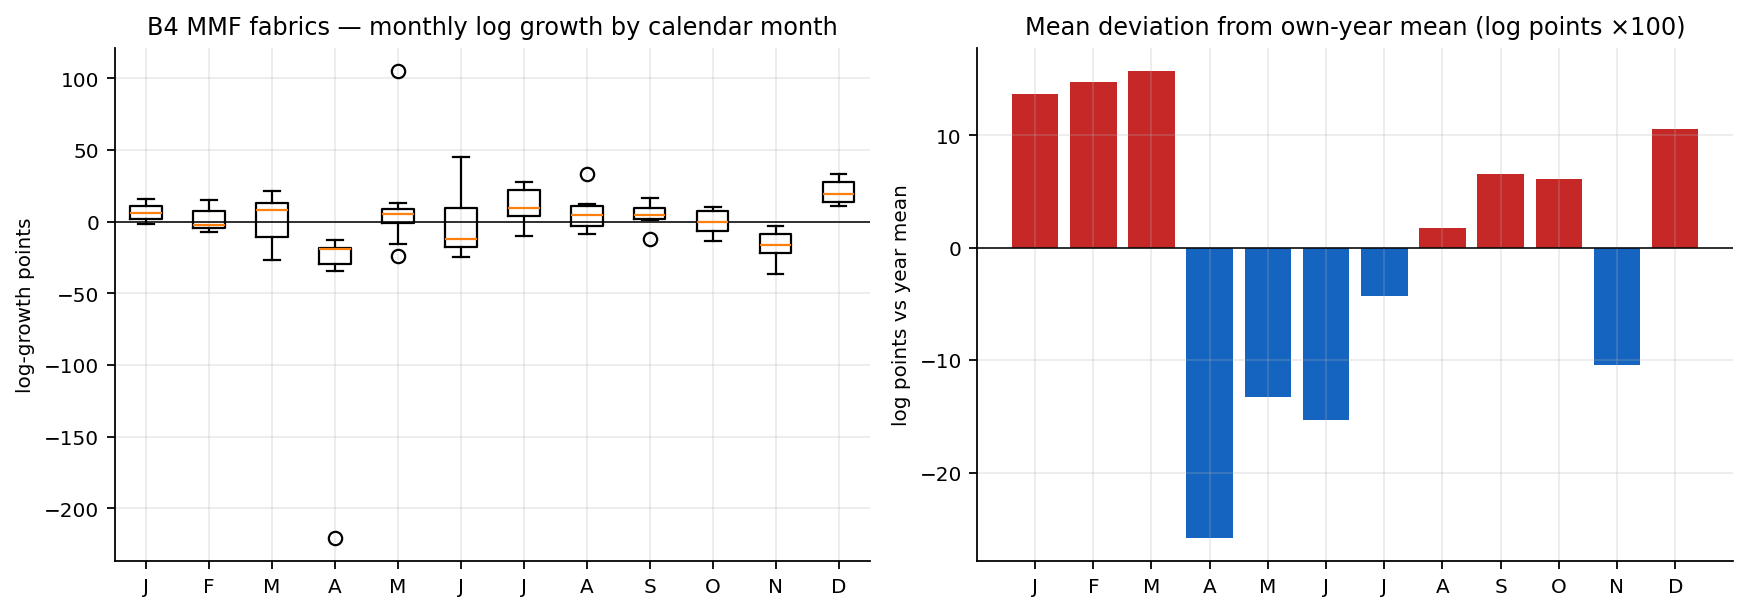

,basket_id,m01,m02,m03,m04,m05,m06,m07,m08,m09,m10,m11,m12
0,B1_MOBILE,-0.67,5.95,13.56,-64.68,-25.36,-20.50,-4.02,-7.20,-12.48,26.27,48.09,41.04
1,B2_PHARMA,-6.52,-4.63,9.13,-4.79,-4.11,2.06,-0.23,1.42,5.65,-0.65,-4.75,7.43
2,B3_AC,-12.96,3.05,15.33,-38.41,-2.53,3.10,6.45,5.29,9.22,-2.79,0.18,14.07
3,B4_TEXTILE,13.65,14.72,15.73,-25.83,-13.26,-15.36,-4.31,1.78,6.55,6.16,-10.39,10.56


In [4]:
show(E.plot_seasonality(df))
E.seasonal_profile(df)

## 5. STL decomposition of log exports

Robust STL, period 12. Reported alongside: Hyndman seasonal and trend strength,
`F = max(0, 1 - Var(remainder) / Var(component + remainder))`.

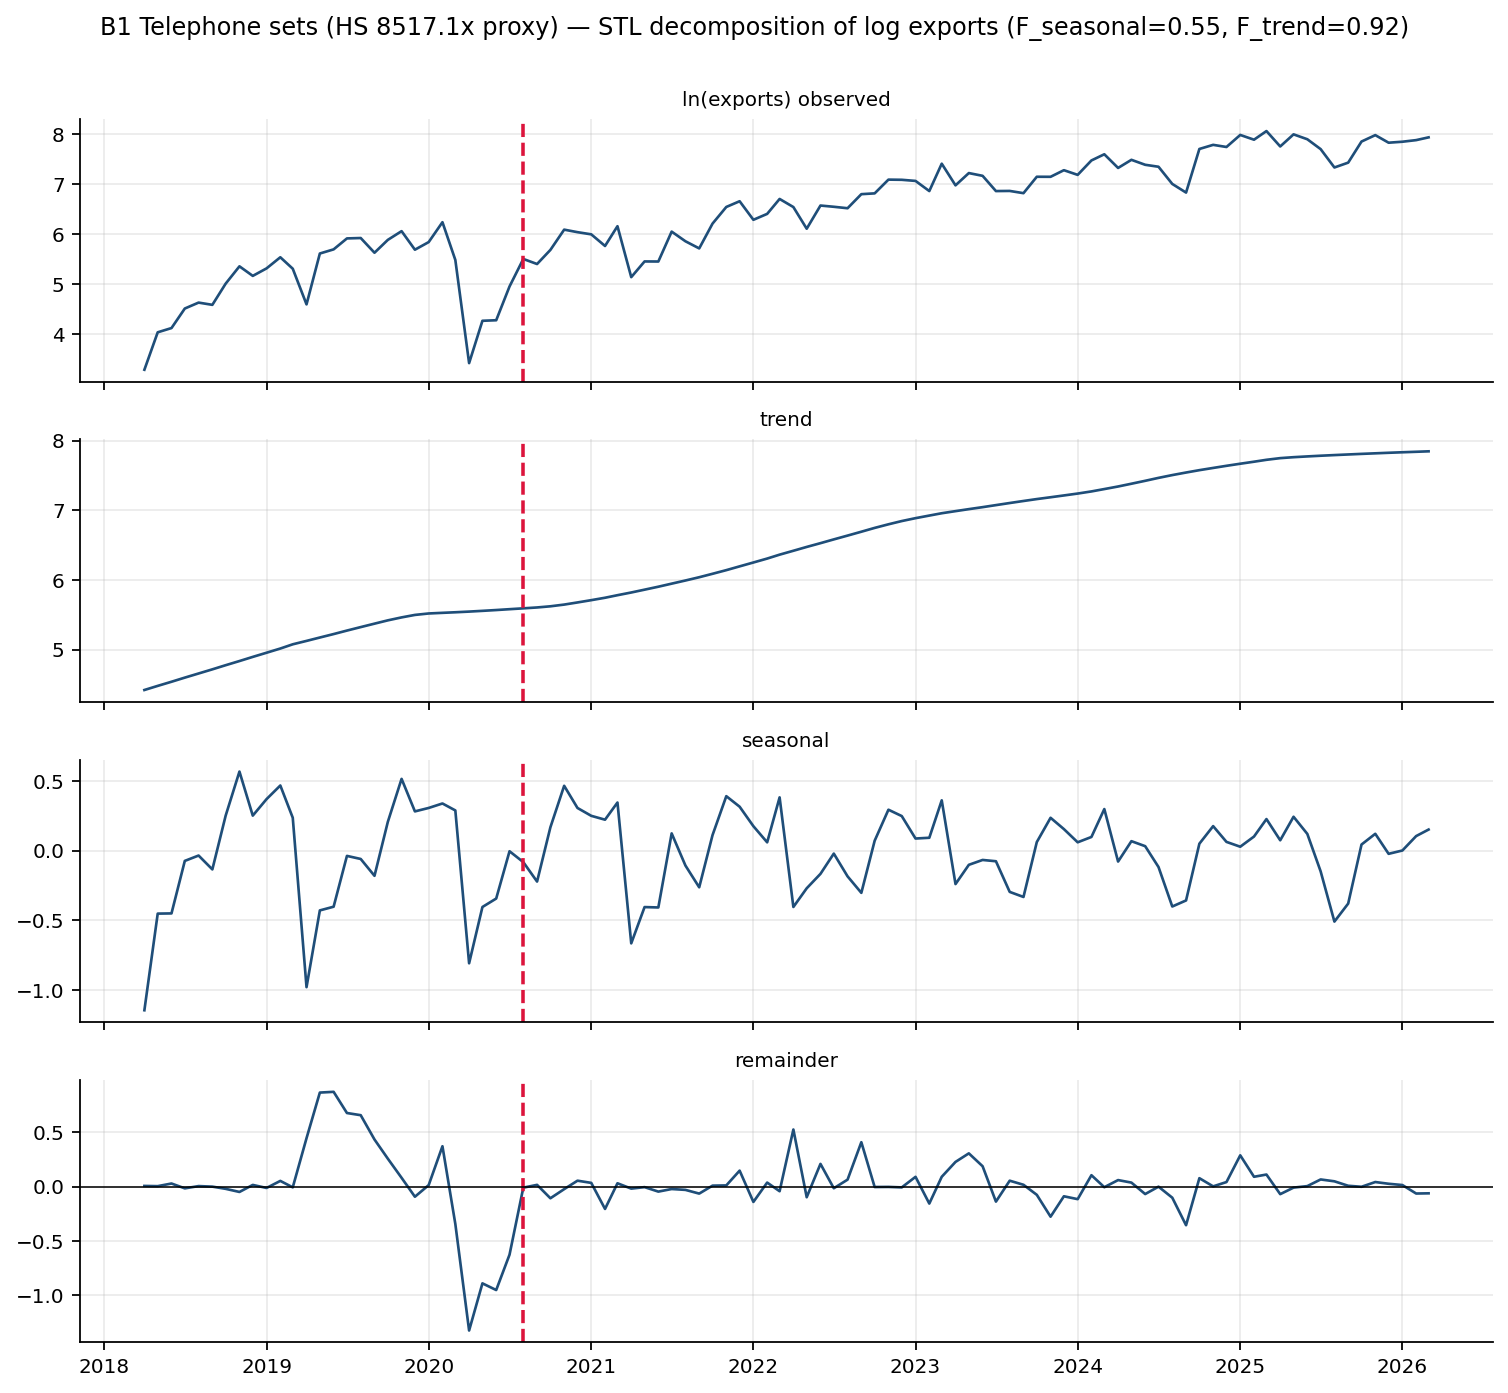

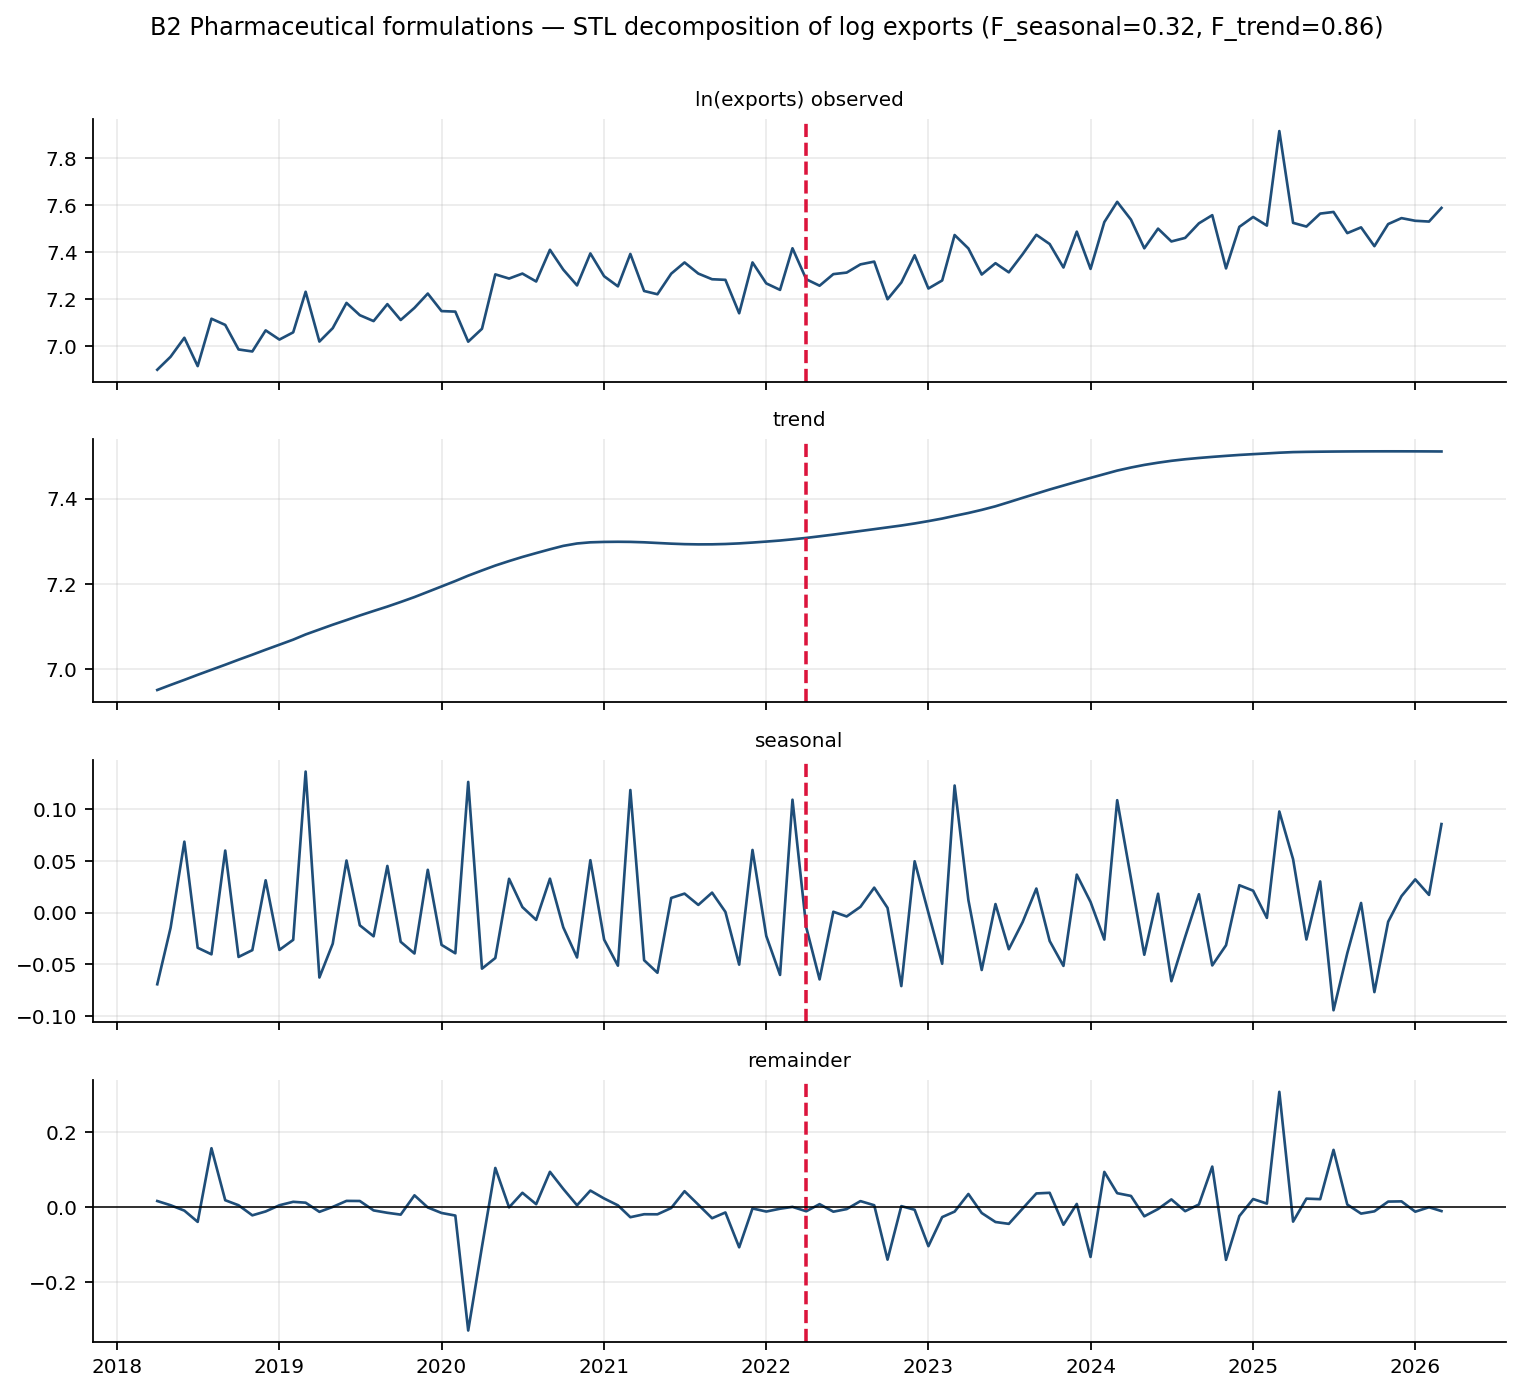

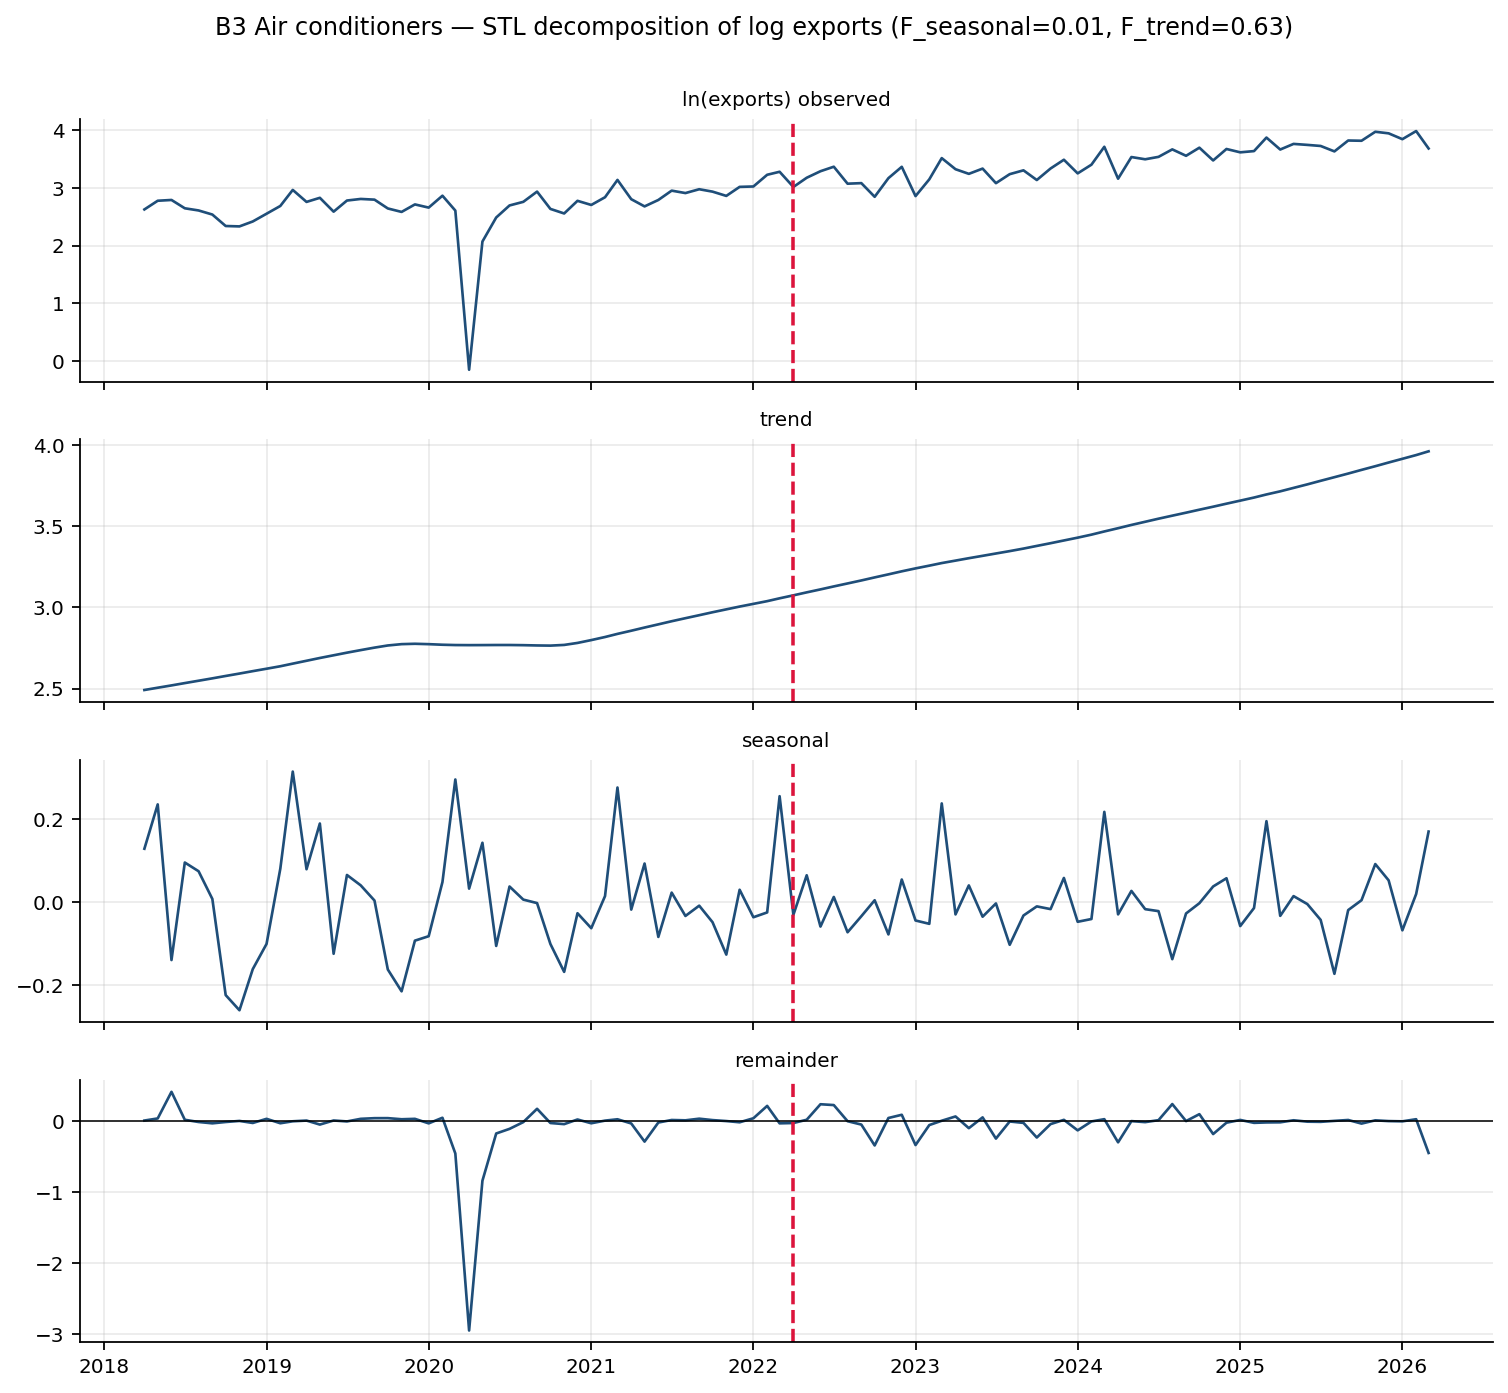

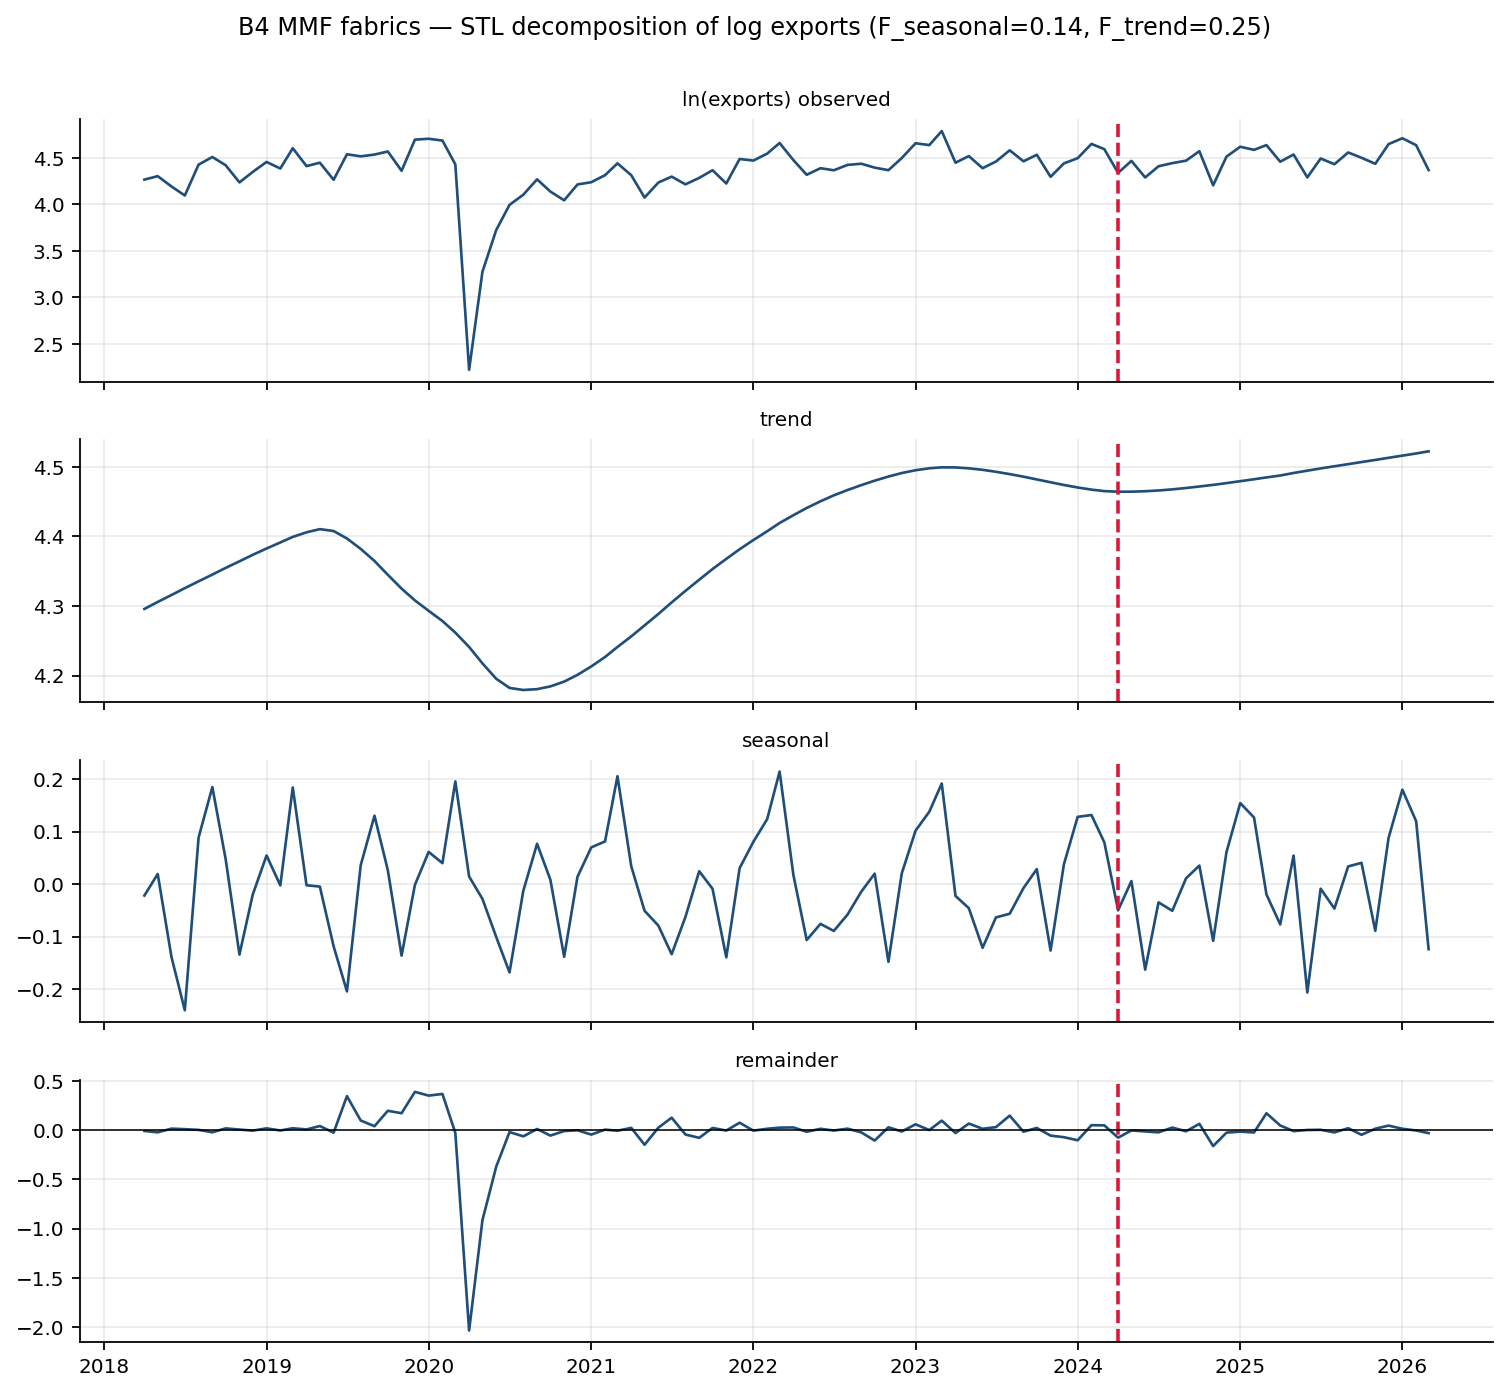

,seasonal_strength,trend_strength,resid_sd_lgp
B1_MOBILE,0.549,0.925,29.35
B2_PHARMA,0.323,0.860,6.64
B3_AC,0.015,0.634,33.43
B4_TEXTILE,0.144,0.249,24.96


In [5]:
figs, strength = E.plot_stl(df)
show(figs)
pd.DataFrame(strength).T

## 6. ACF and PACF — log levels and growth

The 95% band is approximately +/- 1.96/sqrt(n).

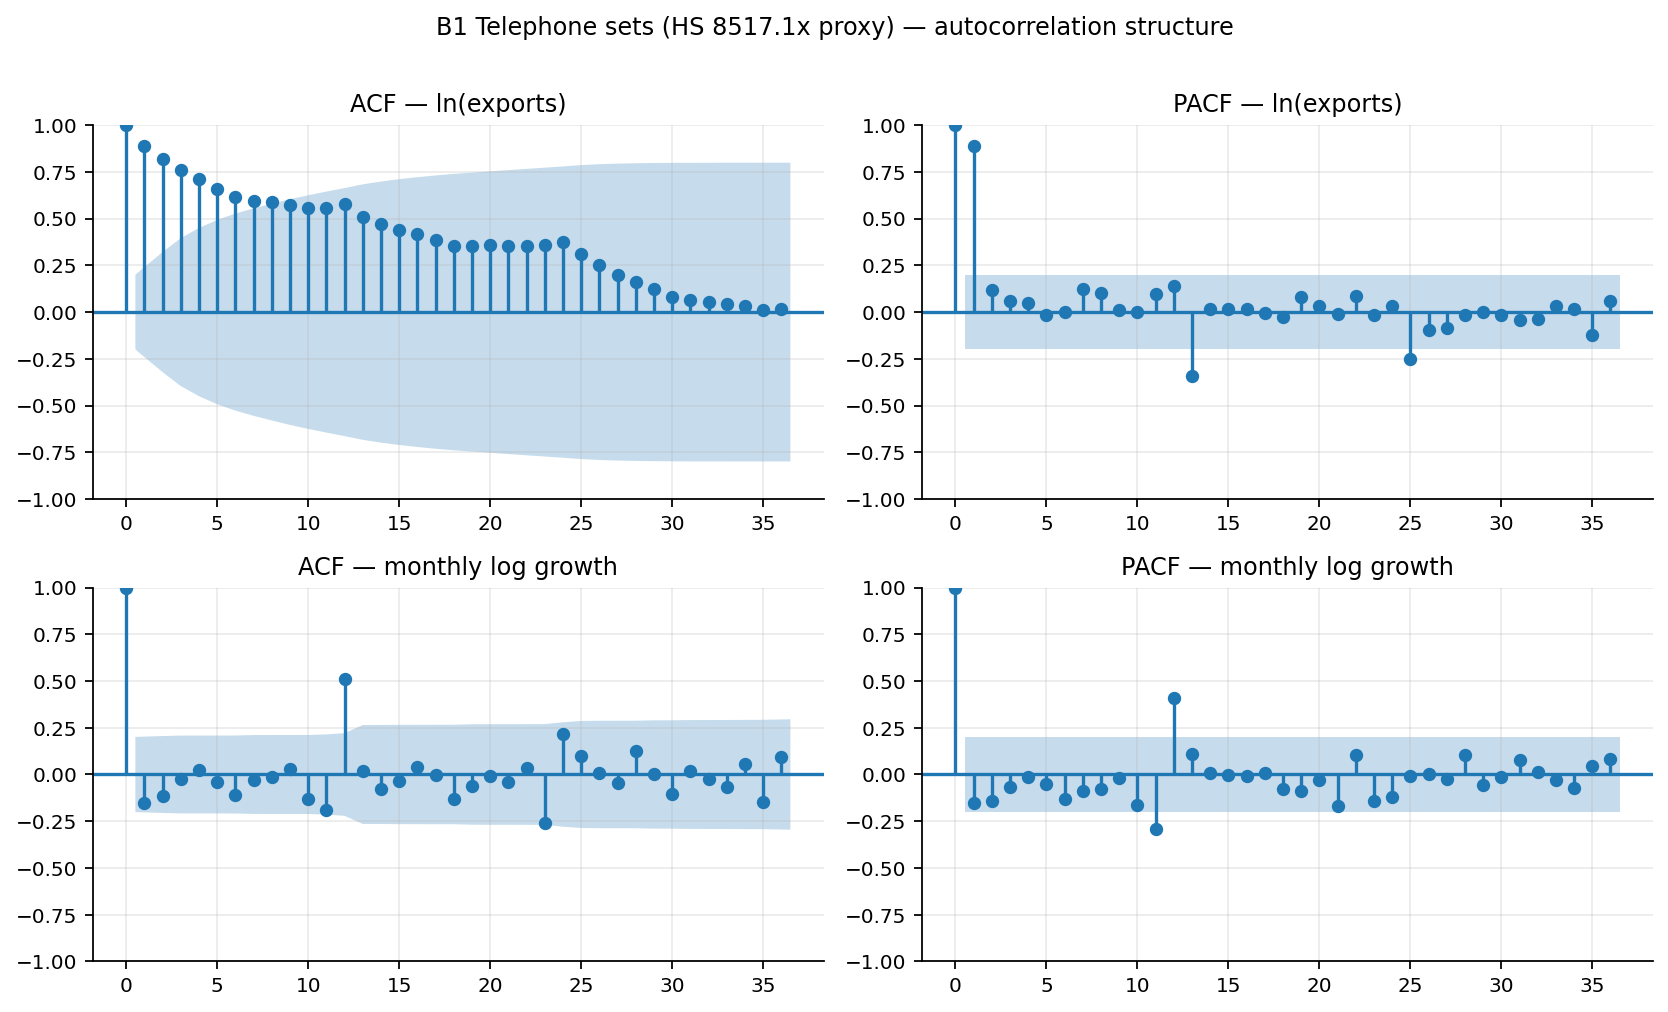

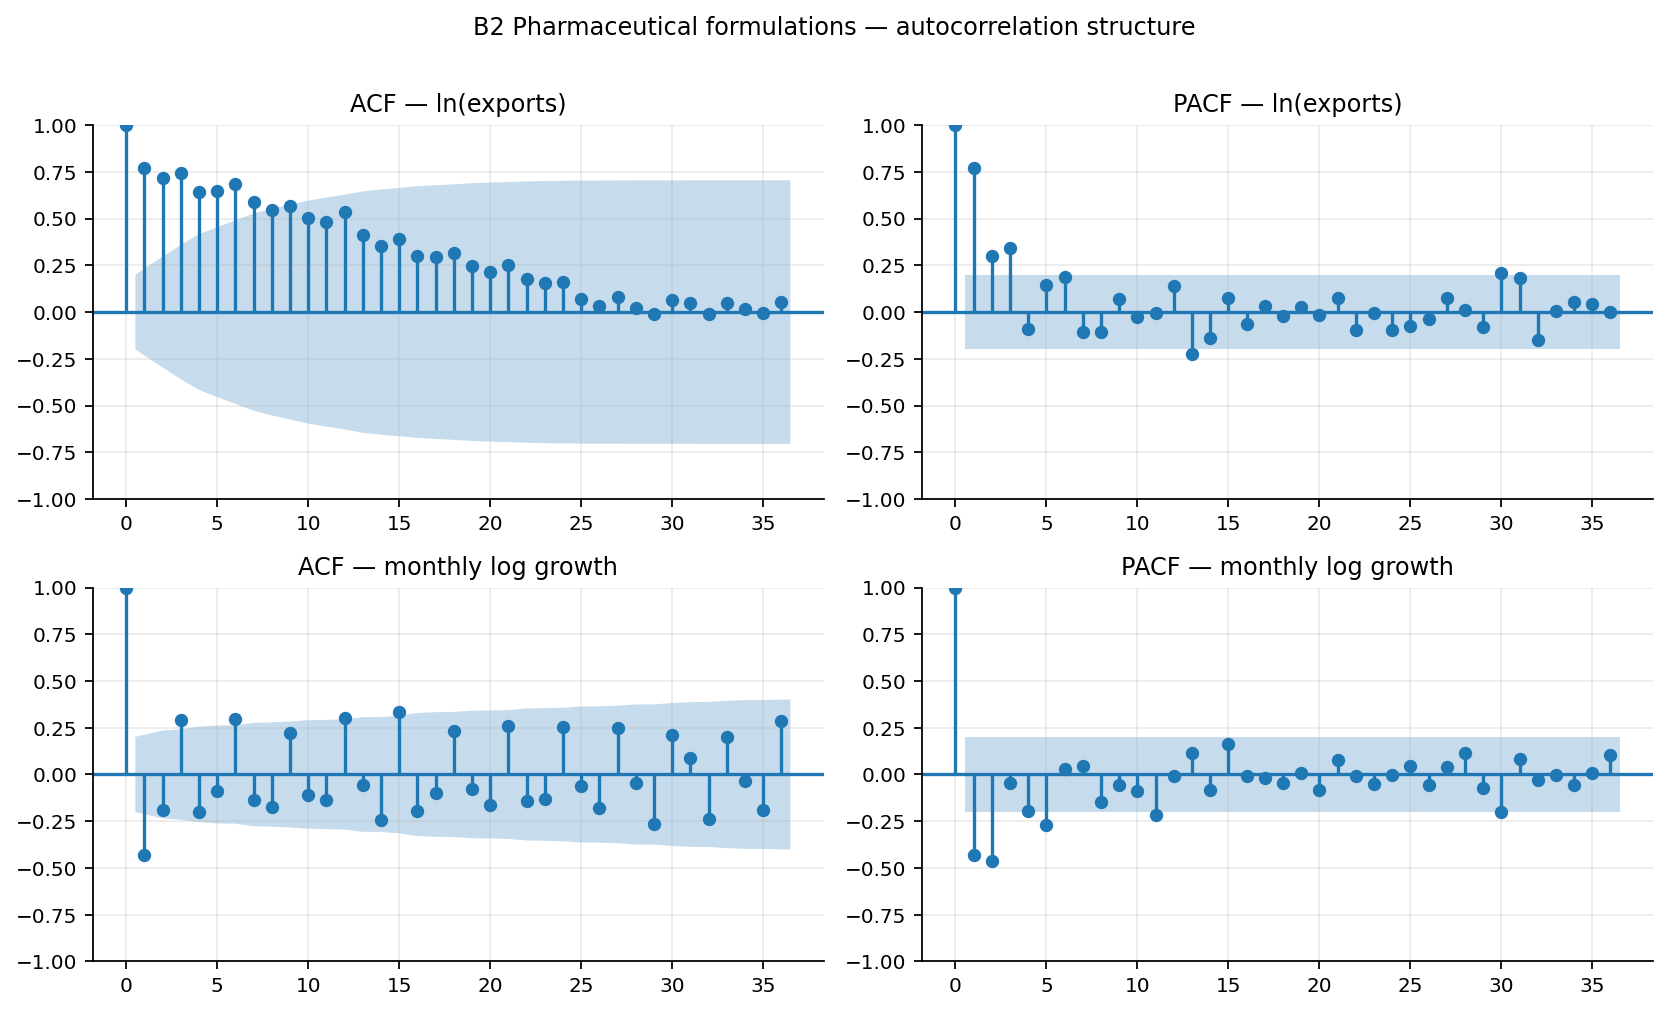

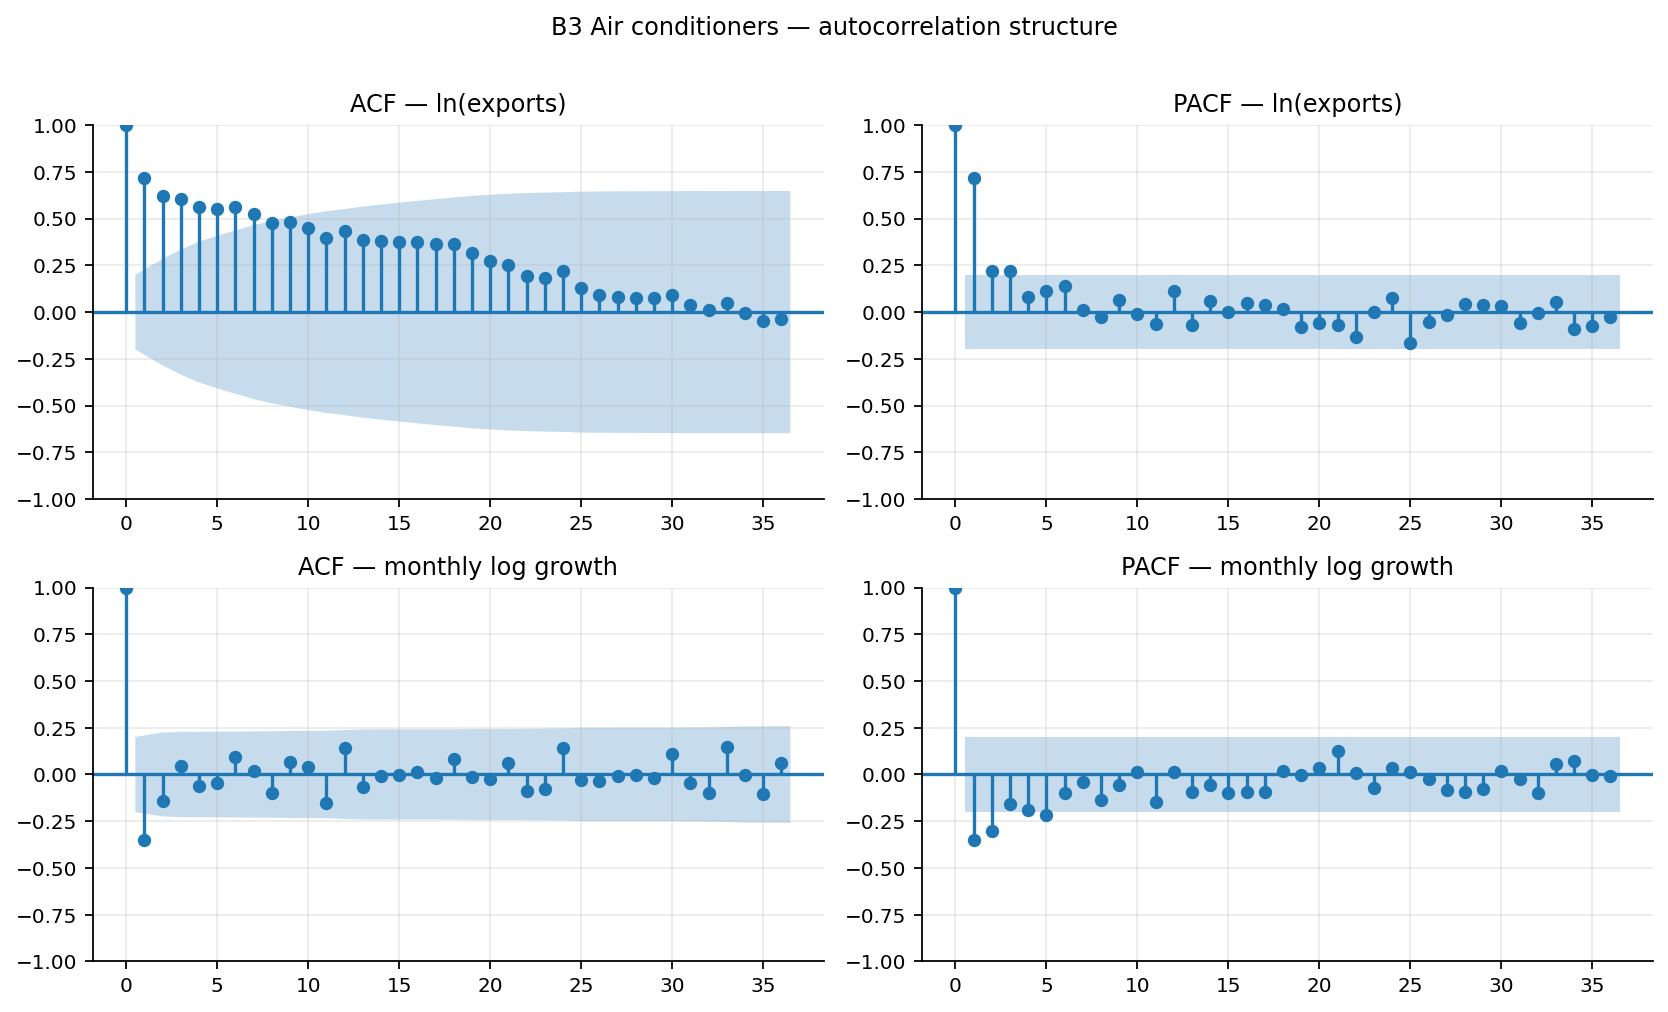

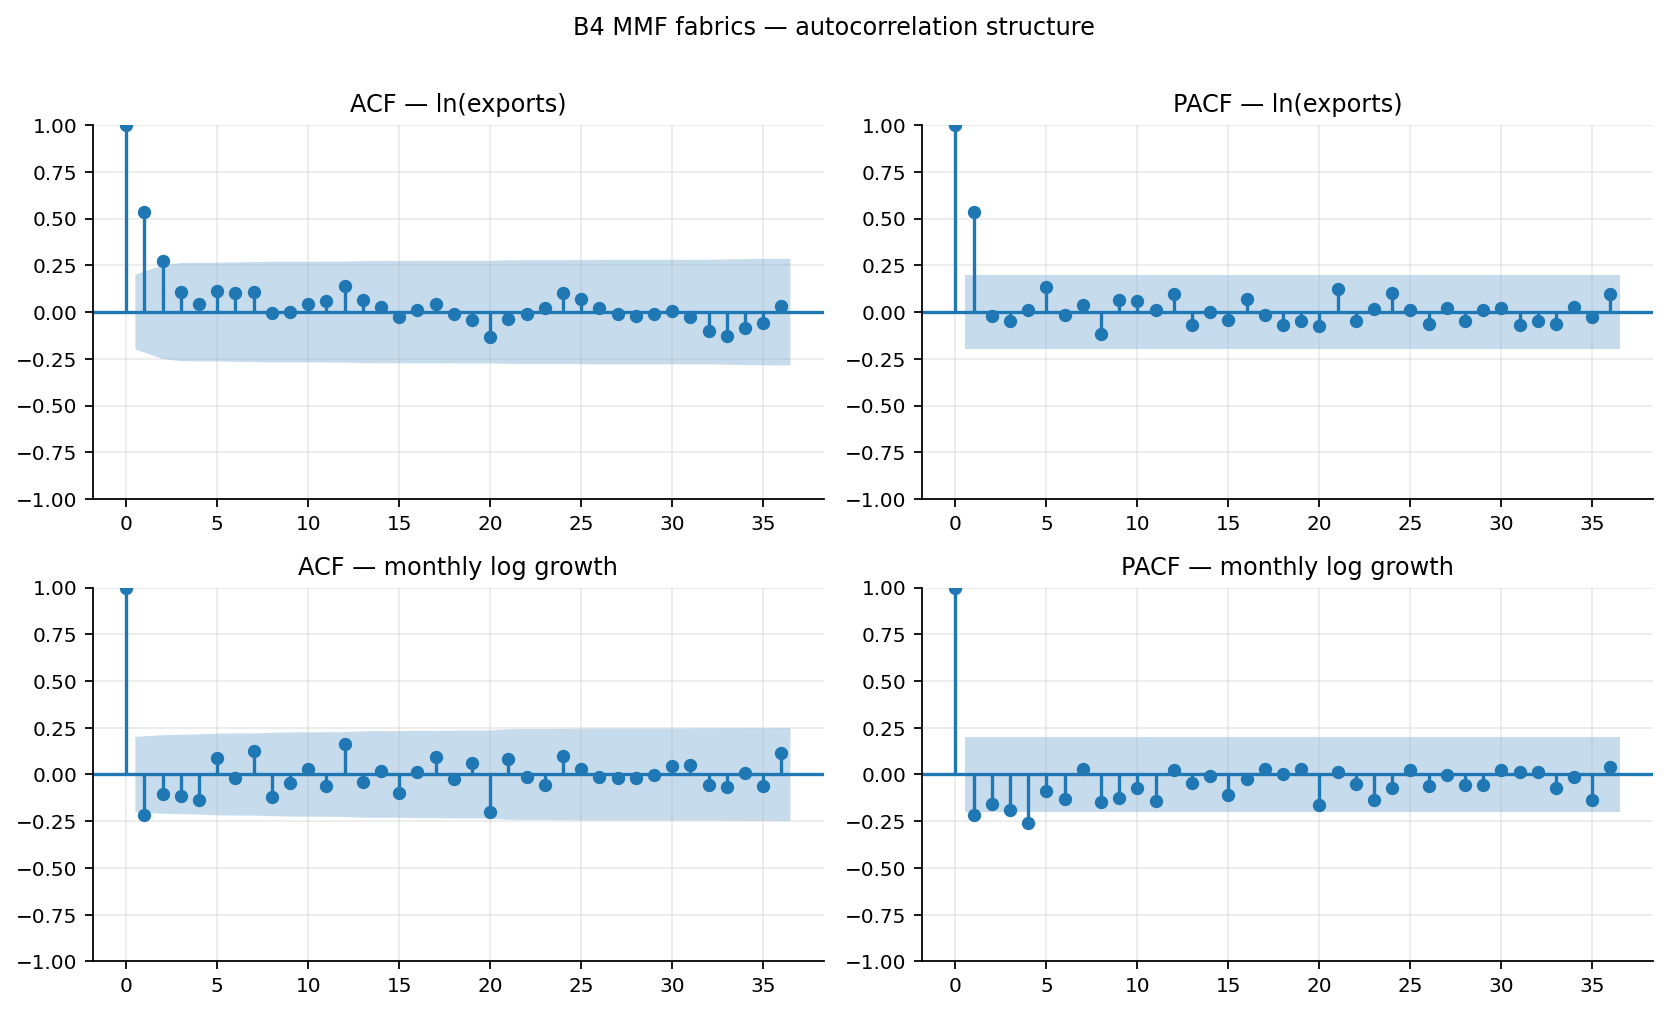

,basket_id,acf1_lnY,acf12_lnY,acf1_growth,acf12_growth,signif_band_95,n_growth
0,B1_MOBILE,0.890,0.577,-0.152,0.512,0.201,95
1,B2_PHARMA,0.773,0.535,-0.430,0.300,0.201,95
2,B3_AC,0.717,0.434,-0.351,0.139,0.201,95
3,B4_TEXTILE,0.534,0.138,-0.218,0.161,0.201,95


In [6]:
show(E.plot_acf_pacf(df))
E.acf_table(df)

## 7–8. Stationarity and break-aware unit-root diagnostics

- **ADF** on `ln(Y)` with constant + trend, and on `g` with constant. Null = unit root.
- **KPSS** with the matching deterministic terms. Null = stationarity. The two test
  opposite nulls and are reported together.
- **Zivot–Andrews** on `ln(Y)`, break allowed in both intercept and trend. This is the
  break-aware diagnostic the design requires: Perron (1989) shows a standard ADF is
  biased *toward* non-rejection when a trend break is present, so a plain ADF cannot
  settle the question on its own.

In [7]:
E.stationarity_table(df)

,basket_id,adf_lnY_ct_stat,adf_lnY_ct_p,adf_lnY_lags,adf_growth_c_stat,adf_growth_c_p,adf_growth_lags,kpss_lnY_ct_stat,kpss_lnY_ct_p,kpss_growth_c_stat,kpss_growth_c_p,za_lnY_stat,za_lnY_p,za_lnY_crit5,za_break
0,B1_MOBILE,-2.589,0.2848,12,-3.278,0.0159,11,0.0586,0.1000,0.1311,0.1000,-4.252,0.3421,-5.073,2020-02
1,B2_PHARMA,-3.957,0.0101,2,-7.911,0.0000,4,0.1423,0.0569,0.1447,0.1000,-4.900,0.0822,-5.073,2021-03
2,B3_AC,-7.138,0.0000,0,-7.188,0.0000,4,0.1305,0.0787,0.5000,0.0417,-8.461,0.0009,-5.073,2020-05
3,B4_TEXTILE,-5.575,0.0000,0,-7.678,0.0000,3,0.0862,0.1000,0.0550,0.1000,-6.775,0.0010,-5.073,2020-02


### 7b. Supplementary — is any stationarity result COVID-driven?

Re-run on growth with Mar–Sep 2020 removed. This is a **diagnostic sensitivity**, not a
change to the locked COVID definition (which remains Apr–Jun 2020).

In [8]:
from statsmodels.tsa.stattools import kpss, adfuller
rows=[]
for b in E.TREATED:
    g = E.series(df,b).g.dropna()
    m = ~((g.index>=pd.Timestamp('2020-03-01')) & (g.index<=pd.Timestamp('2020-09-01')))
    gx = g[m]
    rows.append(dict(basket_id=b,
        kpss_g_p=round(kpss(g,regression='c',nlags='auto')[1],4),
        kpss_g_exCOVID_p=round(kpss(gx,regression='c',nlags='auto')[1],4),
        adf_g_p=round(adfuller(g,regression='c',autolag='AIC')[1],4),
        adf_g_exCOVID_p=round(adfuller(gx,regression='c',autolag='AIC')[1],4)))
pd.DataFrame(rows)

,basket_id,kpss_g_p,kpss_g_exCOVID_p,adf_g_p,adf_g_exCOVID_p
0,B1_MOBILE,0.1000,0.052,0.0159,0.0001
1,B2_PHARMA,0.1000,0.100,0.0000,0.0000
2,B3_AC,0.0417,0.100,0.0000,0.0000
3,B4_TEXTILE,0.1000,0.100,0.0000,0.1259


### 6b. Ljung–Box on monthly log growth — is autocorrelation formally present?

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox
rows=[]
for b in E.TREATED:
    g = E.series(df,b).g.dropna()
    lb = acorr_ljungbox(g, lags=[6,12,24], return_df=True)
    rows.append(dict(basket_id=b, **{f"LB{L}_p": round(lb.loc[L,'lb_pvalue'],4) for L in (6,12,24)}))
pd.DataFrame(rows)

,basket_id,LB6_p,LB12_p,LB24_p
0,B1_MOBILE,0.5371,0.0001,0.0001
1,B2_PHARMA,0.0000,0.0000,0.0000
2,B3_AC,0.0153,0.0356,0.2338
3,B4_TEXTILE,0.1338,0.1637,0.3138


## 9. Six-month rolling volatility

Rolling SD of monthly log growth. **Descriptive only** — the pre/post volatility
comparison, its symmetric +/-24-month windows and all inference on it belong to a later
phase and are not computed here.

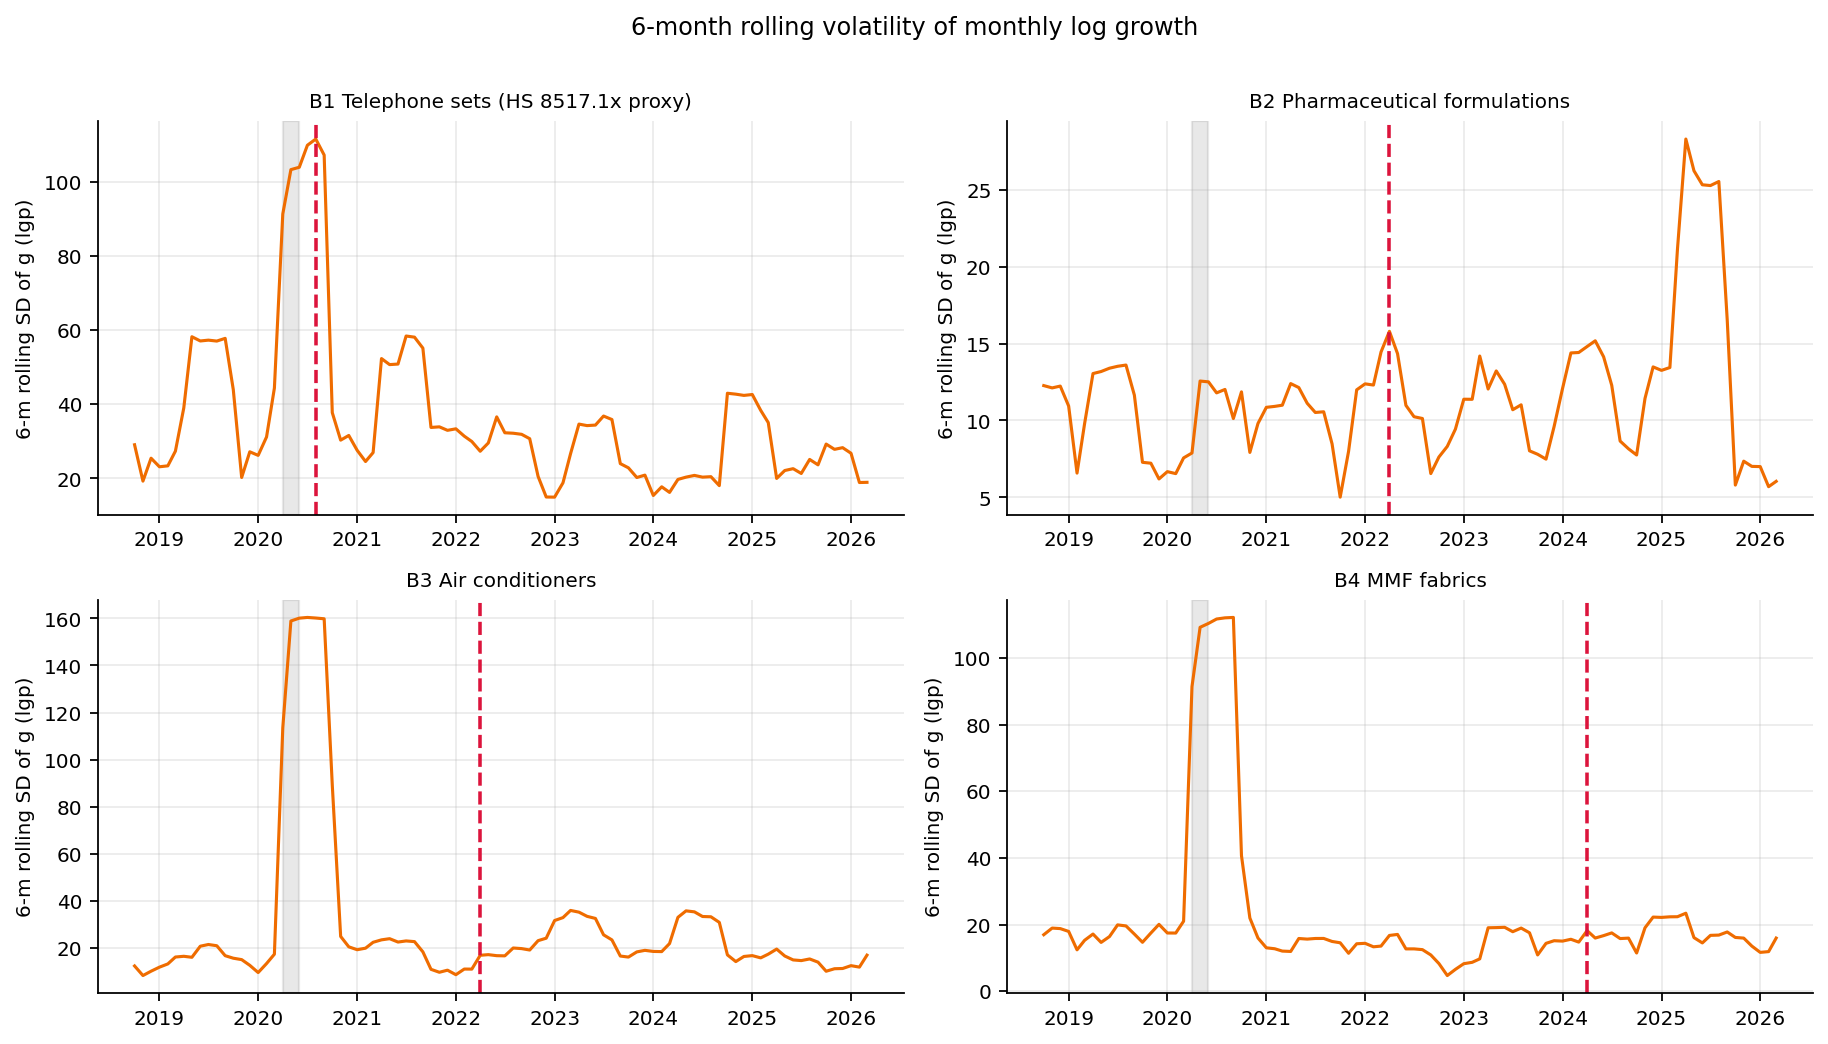

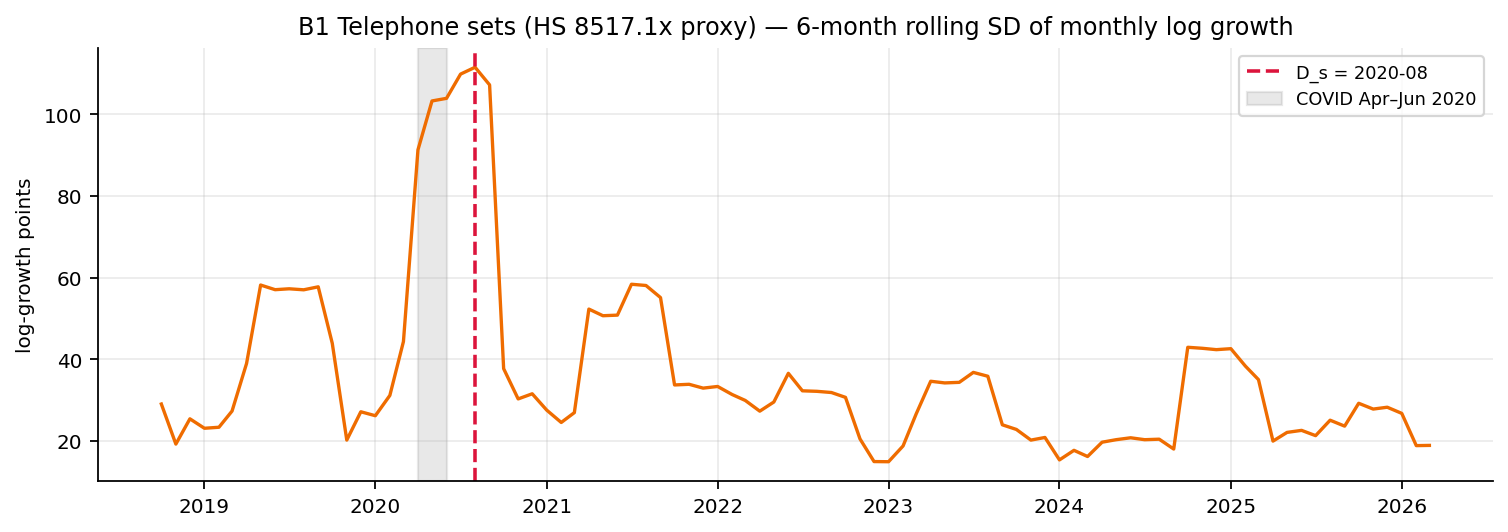

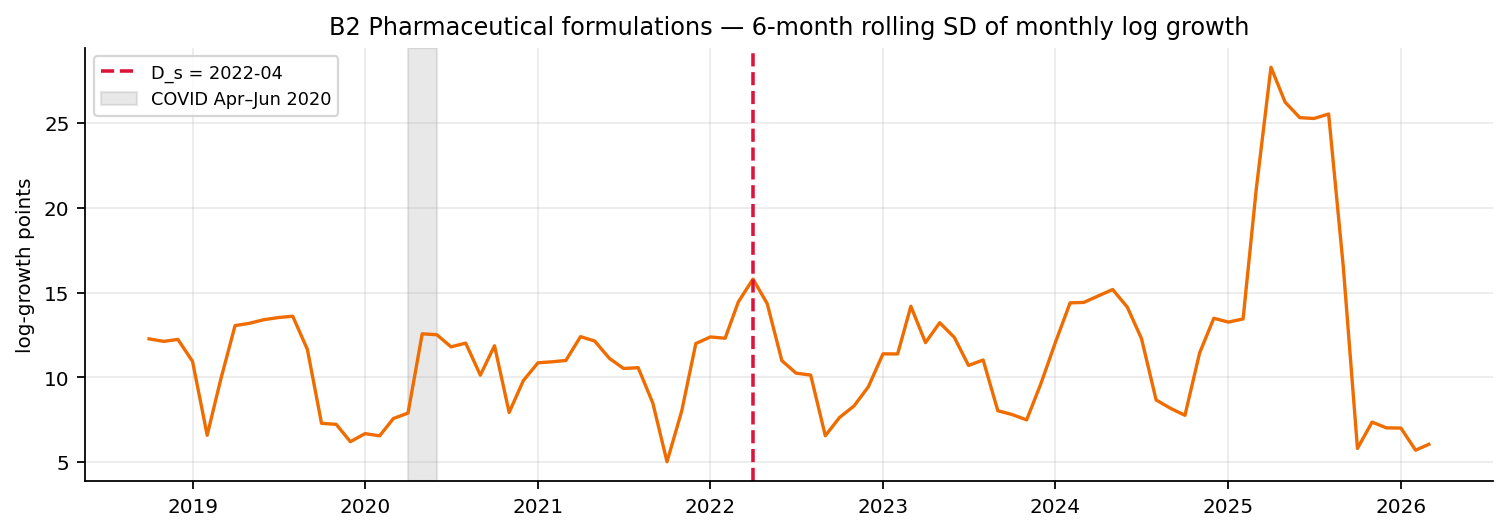

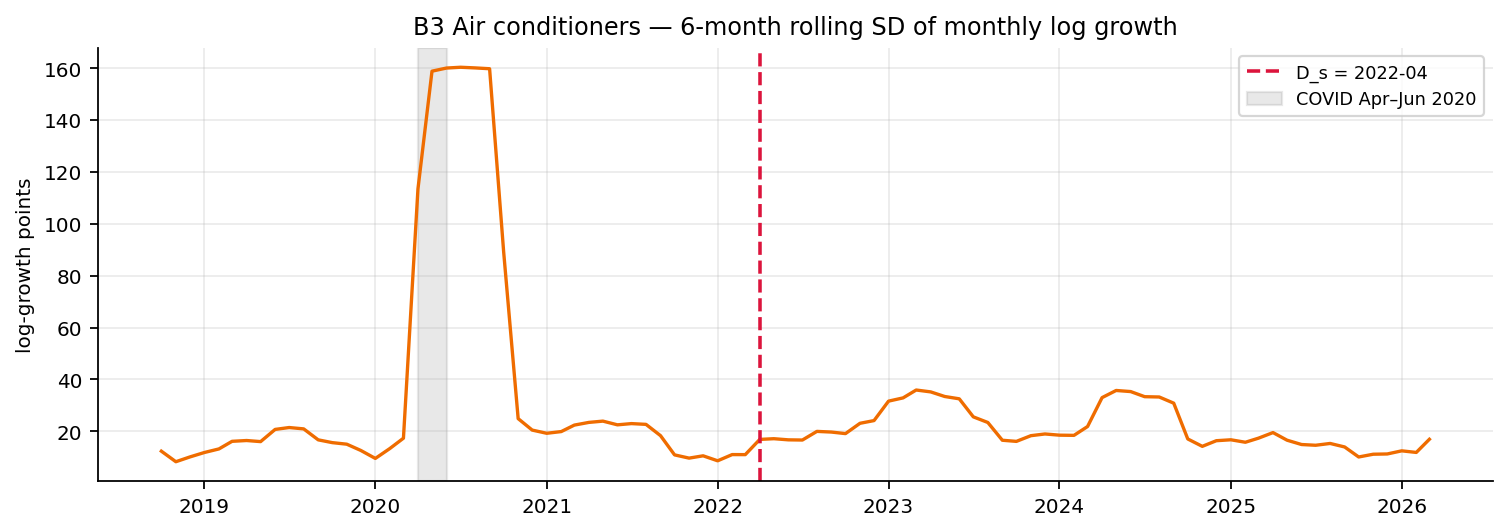

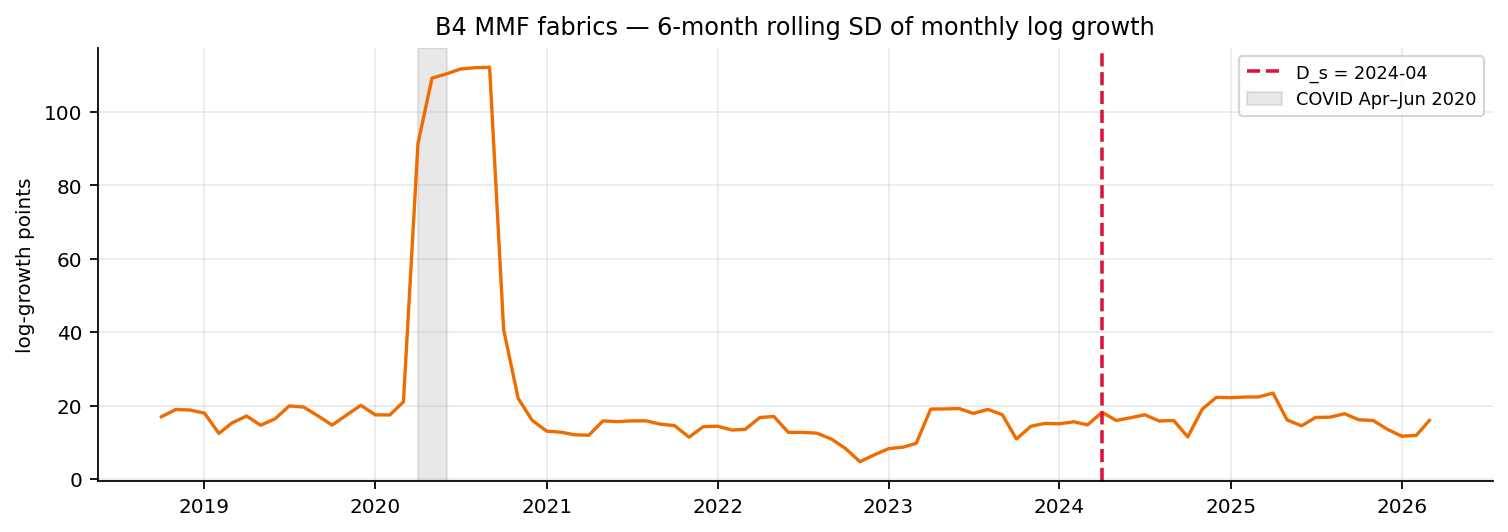

In [10]:
show(E.plot_rolling_vol(df))

### 9b. Does growth volatility depend on the level?

Directly relevant to the later pre/post volatility comparison: if `|g|` is larger when
the series is small, an early-period basket will look more volatile for reasons that
have nothing to do with policy. Reported now so the caveat is on record **before** any
volatility inference is run.

In [11]:
rows=[]
for b in E.TREATED:
    s = E.series(df,b).dropna(subset=['g'])
    lo,hi = s.ln_y.quantile(.33), s.ln_y.quantile(.67)
    t = s[~((s.index>=pd.Timestamp('2020-03-01')) & (s.index<=pd.Timestamp('2020-09-01')))]
    lo2,hi2 = t.ln_y.quantile(.33), t.ln_y.quantile(.67)
    rows.append(dict(basket_id=b,
        sd_low_third=round(s.loc[s.ln_y<=lo,'g'].std(),2),
        sd_high_third=round(s.loc[s.ln_y>=hi,'g'].std(),2),
        ratio=round(s.loc[s.ln_y<=lo,'g'].std()/s.loc[s.ln_y>=hi,'g'].std(),2),
        ratio_exCOVID=round(t.loc[t.ln_y<=lo2,'g'].std()/t.loc[t.ln_y>=hi2,'g'].std(),2)))
pd.DataFrame(rows)

,basket_id,sd_low_third,sd_high_third,ratio,ratio_exCOVID
0,B1_MOBILE,58.79,25.41,2.31,1.52
1,B2_PHARMA,9.94,13.27,0.75,0.76
2,B3_AC,65.76,16.85,3.90,0.91
3,B4_TEXTILE,46.87,10.33,4.54,1.36


## 10. EDA findings table

Full tidy output in `06_results/EDA_summary.csv`.
Narrative reading in `08_report/EDA_findings.md`.

In [12]:
# Build and save the tidy EDA findings table (06_results/EDA_summary.csv).
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
rec=[]
def add(block,b,metric,val,note=""):
    rec.append(dict(block=block,basket_id=b,metric=metric,
        value=(round(val,4) if isinstance(val,(int,float,np.floating)) and not pd.isna(val) else val),note=note))
UNIT="log-growth points (lgp) - NOT percentage growth"
for _,r in E.descriptives(df).iterrows():
    for k,v in r.items():
        if k!="basket_id": add("descriptives",r.basket_id,k,v, UNIT if "growth" in k else "")
for _,r in E.heteroskedasticity_check(df).iterrows():
    for k,v in r.items():
        if k!="basket_id": add("log_transform",r.basket_id,k,v)
_,strength=E.plot_stl(df)
for b,d in strength.items():
    for k,v in d.items(): add("stl",b,k,v,"resid_sd_lgp in log-growth points" if "resid" in k else "")
for _,r in E.seasonal_profile(df).iterrows():
    for k,v in r.items():
        if k!="basket_id": add("seasonal_profile",r.basket_id,k,v,"log points x100 vs own-year mean")
for _,r in E.acf_table(df).iterrows():
    for k,v in r.items():
        if k!="basket_id": add("autocorrelation",r.basket_id,k,v)
for _,r in E.stationarity_table(df).iterrows():
    for k,v in r.items():
        if k!="basket_id": add("stationarity",r.basket_id,k,v,
            "evidence consistent with; no single test establishes integration order")
for b in E.TREATED:
    s=E.series(df,b); g=s.g.dropna()
    m=~((g.index>=pd.Timestamp('2020-03-01'))&(g.index<=pd.Timestamp('2020-09-01'))); gx=g[m]
    add("robust_exCOVID",b,"kpss_growth_p_exCOVID",kpss(gx,regression='c',nlags='auto')[1],"Mar-Sep 2020 removed")
    add("robust_exCOVID",b,"adf_growth_p_exCOVID",adfuller(gx,regression='c',autolag='AIC')[1],"Mar-Sep 2020 removed")
    lb=acorr_ljungbox(g,lags=[6,12,24],return_df=True)
    for L in (6,12,24): add("ljung_box",b,f"LB{L}_p_growth",lb.loc[L,'lb_pvalue'])
    sv=s.dropna(subset=['g']); lo,hi=sv.ln_y.quantile(.33),sv.ln_y.quantile(.67)
    t=sv[~((sv.index>=pd.Timestamp('2020-03-01'))&(sv.index<=pd.Timestamp('2020-09-01')))]
    lo2,hi2=t.ln_y.quantile(.33),t.ln_y.quantile(.67)
    add("level_dependence",b,"sd_growth_low_level_third_lgp",sv.loc[sv.ln_y<=lo,'g'].std(),UNIT)
    add("level_dependence",b,"sd_growth_high_level_third_lgp",sv.loc[sv.ln_y>=hi,'g'].std(),UNIT)
    add("level_dependence",b,"ratio_low_over_high",sv.loc[sv.ln_y<=lo,'g'].std()/sv.loc[sv.ln_y>=hi,'g'].std())
    add("level_dependence",b,"ratio_low_over_high_exCOVID",
        t.loc[t.ln_y<=lo2,'g'].std()/t.loc[t.ln_y>=hi2,'g'].std(),"Mar-Sep 2020 removed")
    for lbl,v in [("simple_pct_min_growth",sv.g.min()),("simple_pct_max_growth",sv.g.max())]:
        add("lgp_to_simple_pct",b,lbl,100*(np.exp(v/100)-1),f"from {v:.2f} lgp; simple % change")
pd.DataFrame(rec).to_csv('../06_results/EDA_summary.csv',index=False)
print("EDA_summary.csv written:",len(rec),"rows")

EDA_summary.csv written: 252 rows


In [13]:
summary = pd.read_csv("../06_results/EDA_summary.csv")
print(summary.shape); summary.groupby("block").size()

(252, 5)


block
autocorrelation      24
descriptives         56
level_dependence     16
lgp_to_simple_pct     8
ljung_box            12
log_transform        12
robust_exCOVID        8
seasonal_profile     48
stationarity         56
stl                  12
dtype: int64

---
## End of EDA

Diagnosis only — no ITS, forecasting, volatility inference, control or robustness model
is estimated in this notebook. Estimation begins in `02_ITS_diagnostics.ipynb`.